# TDAH laboral LATAM: análisis exploratorio de datos con Python

## Objetivo

Explorar la relación entre variables relacionadas con TDAH y situación laboral
en una muestra de personas adultas de Latinoamérica.

## Dataset

- Fuente: encuesta propia mediante Microsoft Forms
- Participantes: 64
- Países: México, Argentina y Guatemala
- Tipo de análisis: exploratorio y descriptivo

> Los resultados corresponden únicamente a la muestra analizada y no son
> representativos de toda la población latinoamericana.

## Preguntas de análisis

1. ¿Qué proporción de participantes reporta diagnóstico formal de TDAH?
2. ¿Qué tipos de TDAH aparecen con mayor frecuencia?
3. ¿Cuál es la distribución de la situación laboral?
4. ¿Qué dificultades laborales se reportan con mayor frecuencia?
5. ¿Qué proporción recibe apoyos o adaptaciones laborales?
6. ¿Qué patrones descriptivos se observan al relacionar el diagnóstico y el tipo de TDAH con la situación laboral, las dificultades y los apoyos laborales?

## 1. Extracción de datos

### Carga del dataset

El dataset utilizado en este proyecto proviene de una encuesta propia realizada mediante Microsoft Forms.

Por motivos de privacidad, el archivo original con las respuestas de los participantes no se incluye públicamente en el repositorio. Al ejecutar el notebook en Google Colab, el usuario debe seleccionar manualmente el archivo Excel correspondiente.

Después de la carga, el dataset pasa por un proceso de anonimización antes de realizar cualquier análisis.

In [ ]:
# Importar librerías necesarias
import pandas as pd
from google.colab import files

# Seleccionar el archivo Excel desde el equipo
archivo_subido = files.upload()

# Obtener automáticamente el nombre del archivo cargado
nombre_archivo = next(iter(archivo_subido))

# Leer el dataset
df = pd.read_excel(nombre_archivo)

# Verificar dimensiones
print(f"Registros: {df.shape[0]}")
print(f"Variables originales: {df.shape[1]}")

Saving Relación entre el TDAH y la situación laboral en Latinoamérica(1-64).xlsx to Relación entre el TDAH y la situación laboral en Latinoamérica(1-64).xlsx
Registros: 64
Variables originales: 17


## 2. Estandarización y Anonimización

In [ ]:
#Renombrar columnas
nuevos_nombres = {
    '¿En qué país vives?': 'pais',
    '¿Cuál es tu edad?': 'edad',
    '¿Cuál es tu nivel de estudios más alto?': 'escolaridad',
    '¿Tienes diagnóstico formal de TDAH?': 'diagnostico_formal',
    '¿A qué edad recibiste el diagnóstico?': 'edad_diagnostico',
    '¿Qué tipo de TDAH tienes?': 'tipo_tdah',
    '¿Actualmente estás trabajando?': 'trabaja_actualmente',
    '¿Qué tipo de trabajo tienes actualmente?': 'modalidad_trabajo',
    '¿Has tenido dificultades laborales relacionadas con tu TDAH?': 'dificultades_laborales',
    '¿Recibes adaptaciones o apoyos en tu entorno laboral?': 'apoyos_laborales'
}

df.rename(columns=nuevos_nombres, inplace=True)

#Eliminar identificadores y metadatos
df = df.drop(columns=[
    'ID',
    'Hora de inicio',
    'Hora de finalización',
    'Correo electrónico',
    'Nombre',
    'Hora de la última modificación',
    '¿Quieres compartir algo más sobre tu experiencia laboral y TDAH?'
])

### Protección de datos y anonimización

Antes de iniciar el análisis se eliminaron identificadores directos, metadatos de la encuesta y respuestas abiertas que pudieran contener información personal de los participantes.

El dataset resultante conserva únicamente las variables necesarias para el análisis, reduciendo el riesgo de exposición de información identificable.

In [ ]:
# Verificar estructura después de la anonimización
print(f"Dataset anonimizado: {df.shape[0]} registros y {df.shape[1]} variables\n")

print("Variables disponibles:")
for columna in df.columns:
    print(f"- {columna}")

Dataset anonimizado: 64 registros y 10 variables

Variables disponibles:
- pais
- edad
- escolaridad
- diagnostico_formal
- edad_diagnostico
- tipo_tdah
- trabaja_actualmente
- modalidad_trabajo
- dificultades_laborales
- apoyos_laborales


## 3. Data Profiling

Antes de realizar la limpieza y transformación de los datos, se realiza una revisión inicial de la estructura y calidad del dataset anonimizado.

Este análisis permite identificar dimensiones, tipos de datos, valores nulos, registros duplicados y características generales de las variables antes de tomar decisiones de preparación y limpieza.

In [ ]:
# Dimensiones del dataset
filas, columnas = df.shape

print(f"Registros: {filas}")
print(f"Variables: {columnas}")

Registros: 64
Variables: 10


In [ ]:
# Tipos de datos por variable
tipos_datos = df.dtypes.to_frame(name='tipo_dato')

display(tipos_datos)

,tipo_dato
pais,object
edad,object
escolaridad,object
diagnostico_formal,object
edad_diagnostico,object
tipo_tdah,object
trabaja_actualmente,object
modalidad_trabajo,object
dificultades_laborales,object
apoyos_laborales,object


In [ ]:
# Valores nulos por variable
valores_nulos = (
    df.isna()
      .sum()
      .to_frame(name='valores_nulos')
)

valores_nulos['porcentaje_nulos'] = (
    valores_nulos['valores_nulos'] / len(df) * 100
).round(2)

valores_nulos = valores_nulos.sort_values(
    by='valores_nulos',
    ascending=False
)

display(valores_nulos)

,valores_nulos,porcentaje_nulos
pais,0,0.0
edad,0,0.0
escolaridad,0,0.0
diagnostico_formal,0,0.0
edad_diagnostico,0,0.0
tipo_tdah,0,0.0
trabaja_actualmente,0,0.0
modalidad_trabajo,0,0.0
dificultades_laborales,0,0.0
apoyos_laborales,0,0.0


In [ ]:
# Registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 0


In [ ]:
# Resumen general de las variables
display(df.describe(include='all').T)

,count,unique,top,freq
pais,64,3,México,60
edad,64,29,37,5
escolaridad,64,4,Universidad,45
diagnostico_formal,64,3,Sí,39
edad_diagnostico,64,42,39,4
tipo_tdah,64,4,Combinado,28
trabaja_actualmente,64,4,Sí,37
modalidad_trabajo,64,14,Tiempo completo,26
dificultades_laborales,64,49,Si,12
apoyos_laborales,64,4,No,26


In [ ]:
# Cardinalidad de las variables
valores_unicos = (
    df.nunique()
      .sort_values()
      .to_frame(name='valores_unicos')
)

display(valores_unicos)

,valores_unicos
pais,3
diagnostico_formal,3
escolaridad,4
tipo_tdah,4
trabaja_actualmente,4
apoyos_laborales,4
modalidad_trabajo,14
edad,29
edad_diagnostico,42
dificultades_laborales,49


In [ ]:
# Revisar consistencia entre situación y modalidad de trabajo

revision_modalidad = (
    df.groupby(
        ['trabaja_actualmente', 'modalidad_trabajo'],
        dropna=False
    )
    .size()
    .reset_index(name='registros')
    .sort_values(
        ['trabaja_actualmente', 'registros'],
        ascending=[True, False]
    )
)

display(revision_modalidad)

,trabaja_actualmente,modalidad_trabajo,registros
0,Buscando empleo,Freelance / Independiente,2
1,Buscando empleo,Informal,1
2,Buscando empleo,No tengo,1
3,Buscando empleo,Tiempo completo,1
4,Buscando empleo,Trabajo en casa,1
5,No,Ama de casa,1
6,No,Freelance / Independiente,1
7,No,Informal,1
8,No,Jubilado,1
9,No,No tengo,1


In [ ]:
columnas_categoricas = [
    'pais',
    'escolaridad',
    'diagnostico_formal',
    'tipo_tdah',
    'trabaja_actualmente',
    'modalidad_trabajo',
    'apoyos_laborales'
]

for columna in columnas_categoricas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False))


--- pais ---
pais
México       60
Argentina     3
Guatemala     1
Name: count, dtype: int64

--- escolaridad ---
escolaridad
Universidad     45
Posgrado        11
Preparatoria     7
Secundaria       1
Name: count, dtype: int64

--- diagnostico_formal ---
diagnostico_formal
Sí                          39
No, pero sospecho que sí    18
No                           7
Name: count, dtype: int64

--- tipo_tdah ---
tipo_tdah
Combinado                  28
No sé                      17
Inatento                   13
Hiperactivo / Impulsivo     6
Name: count, dtype: int64

--- trabaja_actualmente ---
trabaja_actualmente
Sí                           37
Trabajo por cuenta propia    14
No                            7
Buscando empleo               6
Name: count, dtype: int64

--- modalidad_trabajo ---
modalidad_trabajo
Tiempo completo                                26
Freelance / Independiente                      15
Informal                                        9
Medio tiempo                     

### Hallazgos del Data Profiling

El dataset anonimizado contiene **64 registros y 10 variables**. En esta etapa inicial, todas las variables fueron importadas como tipo `object`, incluyendo `edad` y `edad_diagnostico`, lo que indica la necesidad de revisar y convertir las variables que conceptualmente deberían ser numéricas.

No se identificaron valores nulos (`NaN`) ni registros completamente duplicados antes del proceso de limpieza. Sin embargo, la ausencia inicial de valores nulos no implica que todos los datos sean válidos, ya que algunas variables contienen respuestas textuales que posteriormente deberán ser interpretadas o convertidas.

Las variables categóricas presentan diferentes niveles de cardinalidad. Variables como `pais`, `escolaridad`, `diagnostico_formal`, `tipo_tdah`, `trabaja_actualmente` y `apoyos_laborales` presentan un número reducido de categorías. En contraste, `modalidad_trabajo` contiene **14 valores distintos** y `dificultades_laborales` **49**, lo que evidencia respuestas heterogéneas y la necesidad de revisar su estandarización antes del análisis.

La variable `edad_diagnostico` presenta **42 valores distintos** y combina edades numéricas con respuestas textuales relacionadas con la ausencia o desconocimiento de un diagnóstico. Por este motivo, será necesario generar una versión numérica de esta variable conservando como valores faltantes aquellas respuestas que no representan una edad cuantificable.

Estos hallazgos definen las decisiones de limpieza, transformación y estandarización aplicadas en las siguientes etapas.

## 4. Limpieza y Preparación de Datos

### 4.1 Normalización de Variables Categóricas

In [ ]:
#Normalizar país
df['pais'] = df['pais'].str.strip().str.title()

#Limpiar tipo_tdah
df['tipo_tdah'] = df['tipo_tdah'].str.strip()

# Estandarización de modalidad de trabajo

def normalizar_modalidad(row):
    situacion = str(row['trabaja_actualmente']).strip()
    modalidad = str(row['modalidad_trabajo']).strip()

    # Participantes que actualmente no trabajan
    if situacion == 'No':
        return 'No trabaja'

    # Modalidades ya estandarizadas
    if modalidad == 'Tiempo completo':
        return 'Tiempo completo'

    if modalidad == 'Medio tiempo':
        return 'Medio tiempo'

    if modalidad == 'Freelance / Independiente':
        return 'Freelance / Independiente'

    if modalidad == 'Informal':
        return 'Informal'

    # Respuesta abierta claramente compatible con trabajo independiente
    if modalidad == 'Taller propio, horarios depende de alumnos':
        return 'Freelance / Independiente'

    # Respuestas cuya equivalencia no puede inferirse con certeza
    if modalidad in [
        'Terapeuta',
        '36 hrs semana por estudios'
    ]:
        return 'Otra'

    # Personas buscando empleo sin modalidad claramente clasificable
    if situacion == 'Buscando empleo':
        return 'Buscando empleo'

    # Cualquier respuesta no contemplada
    return 'Otra'


df['modalidad_trabajo_limpia'] = df.apply(
    normalizar_modalidad,
    axis=1
)

In [ ]:
# Validar estandarización de modalidad de trabajo

revision_modalidad_limpia = (
    df.groupby(
        [
            'trabaja_actualmente',
            'modalidad_trabajo',
            'modalidad_trabajo_limpia'
        ],
        dropna=False
    )
    .size()
    .reset_index(name='registros')
)

display(revision_modalidad_limpia)

print("\nDistribución final:")

display(
    df['modalidad_trabajo_limpia']
    .value_counts()
    .to_frame(name='registros')
)

,trabaja_actualmente,modalidad_trabajo,modalidad_trabajo_limpia,registros
0,Buscando empleo,Freelance / Independiente,Freelance / Independiente,2
1,Buscando empleo,Informal,Informal,1
2,Buscando empleo,No tengo,Buscando empleo,1
3,Buscando empleo,Tiempo completo,Tiempo completo,1
4,Buscando empleo,Trabajo en casa,Buscando empleo,1
5,No,Ama de casa,No trabaja,1
6,No,Freelance / Independiente,No trabaja,1
7,No,Informal,No trabaja,1
8,No,Jubilado,No trabaja,1
9,No,No tengo,No trabaja,1



Distribución final:


,registros
modalidad_trabajo_limpia,
Tiempo completo,26
Freelance / Independiente,15
Informal,8
No trabaja,7
Medio tiempo,4
Buscando empleo,2
Otra,2


### Resultado de la normalización de modalidad laboral

La variable `modalidad_trabajo` contenía respuestas estandarizadas y respuestas abiertas, por lo que fue necesario crear la variable derivada `modalidad_trabajo_limpia`.

Las respuestas se agruparon únicamente cuando existía información suficiente para determinar una categoría laboral. Por ejemplo, “Taller propio, horarios depende de alumnos” se clasificó como trabajo freelance/independiente, mientras que respuestas ambiguas como “Terapeuta” se conservaron dentro de la categoría “Otra”.

También se identificaron algunas combinaciones entre situación laboral y modalidad de trabajo que pueden parecer inconsistentes. Estas respuestas se conservaron sin modificar cuando no existía evidencia suficiente para asumir que se trataba de un error de captura.

Después de la estandarización se conservaron los 64 registros originales y la variable quedó agrupada en siete categorías de modalidad laboral.

### 4.2 Conversión de Variables Numéricas

### Tratamiento de variables de edad

Las variables `edad` y `edad_diagnostico` fueron revisadas antes de su utilización en el análisis.

La variable `edad` contiene **2 valores faltantes de un total de 64 registros (3.1 %)**. Debido a que no existe información suficiente para determinar la edad de estas personas, los valores se conservaron como nulos y no se realizó imputación, evitando introducir información artificial en el dataset.

La variable `edad_diagnostico` presentó una mayor heterogeneidad, ya que combinaba edades numéricas con respuestas textuales relacionadas con la ausencia de diagnóstico, desconocimiento de la edad de diagnóstico o respuestas abiertas.

Para su tratamiento se creó la variable `edad_diagnostico_limpia`. Las respuestas que contenían una edad inequívoca dentro de texto, como "A los 15" o "33 años", fueron transformadas a su valor numérico correspondiente. Las respuestas que no proporcionaban una edad cuantificable se conservaron como valores nulos (`NA`).

También se identificaron tres registros con valor `0`. Al contrastarlos con la variable `diagnostico_formal`, se comprobó que correspondían a participantes que indicaron no contar con diagnóstico formal, por lo que estos valores fueron tratados como no aplicables y convertidos a `NA`.

Las respuestas ambiguas, como "7 u 8 años", tampoco fueron imputadas, ya que seleccionar una edad específica implicaría introducir información no proporcionada por la persona participante.

Después del proceso de limpieza se identificaron **16 registros sin una edad de diagnóstico cuantificable**. Estos valores se conservaron como nulos para mantener la integridad de la información original.

In [ ]:
# Convertir edad

df['edad'] = pd.to_numeric(
    df['edad'],
    errors='coerce'
).astype('Int64')

# Crear y limpiar edad de diagnóstico

import re

def limpiar_edad_diagnostico(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().lower()

    # Respuestas que no proporcionan una edad de diagnóstico
    respuestas_sin_edad = [
        'aún no lo sé',
        'no tengo diagnóstico aún',
        'no',
        'no sé diagnóstico',
        'no he recibido diagnóstico',
        'no he recibido',
        'aun no',
        'me falta hacerme estudios',
        '//',
        'no he recibido dx'
    ]

    if texto in respuestas_sin_edad:
        return pd.NA

    # 0 corresponde a participantes sin diagnóstico formal
    if texto == '0':
        return pd.NA

    # Extraer edades expresadas dentro de texto:
    # "A los 16", "33 años", etc.
    numeros = re.findall(r'\d+', texto)

    if len(numeros) == 1:
        return int(numeros[0])

    # Respuestas ambiguas como "7 u 8 años"
    if len(numeros) > 1:
        return pd.NA

    # Respuestas abiertas sin edad cuantificable
    return pd.NA


df['edad_diagnostico_limpia'] = (
    df['edad_diagnostico']
    .apply(limpiar_edad_diagnostico)
    .astype('Int64')
)

# Revisión de valores nulos

print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
pais                         0
edad                         2
escolaridad                  0
diagnostico_formal           0
edad_diagnostico             0
tipo_tdah                    0
trabaja_actualmente          0
modalidad_trabajo            0
dificultades_laborales       0
apoyos_laborales             0
modalidad_trabajo_limpia     0
edad_diagnostico_limpia     16
dtype: int64


### Tratamiento de la edad de diagnóstico

La variable `edad_diagnostico` contenía una combinación de edades numéricas y respuestas textuales. Para facilitar su análisis se creó la variable derivada `edad_diagnostico_limpia`, conservando la variable original para mantener la trazabilidad del proceso.

Las respuestas que contenían una única edad identificable se transformaron a valores numéricos. Las respuestas que no permitían determinar una edad exacta, expresaban ausencia de diagnóstico o contenían valores no válidos se conservaron como valores faltantes (`NA`).

No se realizó imputación de las edades faltantes, ya que no existía información suficiente para estimarlas sin introducir supuestos adicionales.

Como resultado, 48 de los 64 registros cuentan con una edad de diagnóstico cuantificable y 16 permanecen como valores faltantes.

In [ ]:
# Validar la transformación de edad de diagnóstico

print("Registros totales:", len(df))

print(
    "Edades de diagnóstico cuantificables:",
    df['edad_diagnostico_limpia'].notna().sum()
)

print(
    "Edades de diagnóstico no cuantificables:",
    df['edad_diagnostico_limpia'].isna().sum()
)

print(
    "Valores menores o iguales a 0:",
    (df['edad_diagnostico_limpia'].dropna() <= 0).sum()
)

print("\nRango de edades de diagnóstico válidas:")
print(
    "Mínimo:",
    df['edad_diagnostico_limpia'].min()
)
print(
    "Máximo:",
    df['edad_diagnostico_limpia'].max()
)

Registros totales: 64
Edades de diagnóstico cuantificables: 48
Edades de diagnóstico no cuantificables: 16
Valores menores o iguales a 0: 0

Rango de edades de diagnóstico válidas:
Mínimo: 15
Máximo: 56


In [ ]:
# Validación final de edad de diagnóstico

edades_validas = df['edad_diagnostico_limpia'].dropna()

print(f"Registros totales: {len(df)}")
print(f"Edades cuantificables: {edades_validas.shape[0]}")
print(
    "Edades no cuantificables:",
    df['edad_diagnostico_limpia'].isna().sum()
)
print(
    "Edades iguales o menores a 0:",
    (edades_validas <= 0).sum()
)

print("\nRango de edades válidas:")
print(f"Mínimo: {edades_validas.min()}")
print(f"Máximo: {edades_validas.max()}")

Registros totales: 64
Edades cuantificables: 48
Edades no cuantificables: 16
Edades iguales o menores a 0: 0

Rango de edades válidas:
Mínimo: 15
Máximo: 56


### 4.3 Codificación de Dificultades Laborales

### Categorización de dificultades laborales

La variable `dificultades_laborales` contiene respuestas abiertas en las que una misma persona puede mencionar más de una dificultad.

Debido a esta característica, se utilizó una estrategia de **codificación temática multietiqueta**, que permite asignar varias categorías a una misma respuesta sin modificar ni eliminar el texto original proporcionado por los participantes.

Las categorías se definieron de forma exploratoria a partir de los temas recurrentes observados en las respuestas. La clasificación se apoyó en reglas basadas en palabras y expresiones clave, seguida de una revisión manual de las respuestas no clasificadas y de los casos asignados.

Esta categorización se utiliza únicamente con fines descriptivos y no representa una escala clínica ni un instrumento diagnóstico validado.

In [ ]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""

    texto = str(texto).lower().strip()

    # Eliminar acentos para facilitar búsqueda de palabras clave
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    return texto

In [ ]:
# Crear indicador general de dificultad laboral reportada

def clasificar_reporte_dificultad(texto):
    if pd.isna(texto):
        return 'No determinado'

    texto = normalizar_texto(texto)

    respuestas_no = [
        'no',
        'afortunadamente no'
    ]

    respuestas_ambiguas = [
        'no he recibido diagnostico'
    ]

    if texto in respuestas_no:
        return 'No'

    if texto in respuestas_ambiguas:
        return 'No determinado'

    # El resto contiene una afirmación o descripción de dificultades
    return 'Sí'


df['reporta_dificultad'] = (
    df['dificultades_laborales']
    .apply(clasificar_reporte_dificultad)
)

In [ ]:
categorias_dificultades = {

    'atencion_concentracion': [
        'concentr',
        'atencion',
        'distra',
        'enfoc',
        'disoci',
        'estimulo'
    ],

    'organizacion_planificacion': [
        'organiz',
        'planific',
        'desorden',
        'orden',
        'planeacion'
    ],

    'gestion_tiempo_puntualidad': [
        'tiempo',
        'puntual',
        'tarde',
        'horario',
        'plazo',
        'entrega'
    ],

    'memoria_seguimiento': [
        'olvid',
        'recordar',
        'memoria',
        'apuntes',
        'pagos'
    ],

    'regulacion_emocional_estres': [
        'frustr',
        'ansiedad',
        'estres',
        'burnout',
        'abrum',
        'emocional'
    ],

    'motivacion_aburrimiento': [
        'aburr',
        'rutina',
        'motivacion'
    ],

    'comunicacion_relaciones': [
        'comunicar',
        'companero',
        'gente',
        'discrimin',
        'segrega',
        'roces'
    ],

    'impulsividad': [
        'impulsiv'
    ],

    'sobrecarga_agotamiento': [
        'agot',
        'cans',
        'sobrecarga'
    ],

    'comprension_instrucciones': [
        'instruccion',
        'indicacion',
        'comprender',
        'percibir todo lo que se dice'
    ],

    'resolucion_problemas': [
        'sacar cuentas',
        'abordar situaciones',
        'planes de crecimiento'
    ]
}

In [ ]:
# Crear versión temporal normalizada del texto
texto_dificultades = (
    df['dificultades_laborales']
    .apply(normalizar_texto)
)

# Crear una variable binaria por categoría
for categoria, palabras in categorias_dificultades.items():

    df[categoria] = texto_dificultades.apply(
        lambda texto: int(
            any(palabra in texto for palabra in palabras)
        )
    )

In [ ]:
# Identificar las columnas correspondientes a las categorías de dificultades
columnas_dificultades = list(categorias_dificultades.keys())

# Contar cuántas categorías recibió cada respuesta
df['numero_categorias_dificultad'] = (
    df[columnas_dificultades]
    .sum(axis=1)
)

print("Categorías utilizadas:")
print(columnas_dificultades)

print("\nNúmero de categorías asignadas por respuesta:")
display(
    df['numero_categorias_dificultad']
    .value_counts()
    .sort_index()
    .to_frame(name='registros')
)

Categorías utilizadas:
['atencion_concentracion', 'organizacion_planificacion', 'gestion_tiempo_puntualidad', 'memoria_seguimiento', 'regulacion_emocional_estres', 'motivacion_aburrimiento', 'comunicacion_relaciones', 'impulsividad', 'sobrecarga_agotamiento', 'comprension_instrucciones', 'resolucion_problemas']

Número de categorías asignadas por respuesta:


,registros
numero_categorias_dificultad,
0,27
1,21
2,10
3,5
4,1


In [ ]:
display(
    df['reporta_dificultad']
    .value_counts(dropna=False)
    .to_frame(name='registros')
)

,registros
reporta_dificultad,
Sí,58
No,5
No determinado,1


In [ ]:
df['detalle_dificultad'] = df.apply(
    lambda row:
        'Con detalle temático'
        if row['numero_categorias_dificultad'] > 0
        else (
            'Sin dificultad reportada'
            if row['reporta_dificultad'] == 'No'
            else 'Sin detalle suficiente'
        ),
    axis=1
)

display(
    df['detalle_dificultad']
    .value_counts()
    .to_frame(name='registros')
)

,registros
detalle_dificultad,
Con detalle temático,37
Sin detalle suficiente,22
Sin dificultad reportada,5


In [ ]:
# Número de categorías asignadas por participante

distribucion_numero_categorias = (
    df.loc[
        df['detalle_dificultad'] == 'Con detalle temático',
        'numero_categorias_dificultad'
    ]
    .value_counts()
    .sort_index()
    .rename_axis('numero_categorias')
    .to_frame(name='participantes')
)

distribucion_numero_categorias['porcentaje'] = (
    distribucion_numero_categorias['participantes']
    / distribucion_numero_categorias['participantes'].sum()
    * 100
).round(1)

display(distribucion_numero_categorias)

,participantes,porcentaje
numero_categorias,,
1,21,56.8
2,10,27.0
3,5,13.5
4,1,2.7


In [ ]:
# Frecuencia final de categorías de dificultades laborales

resumen_dificultades = (
    df[columnas_dificultades]
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='participantes')
)

resumen_dificultades['porcentaje_muestra'] = (
    resumen_dificultades['participantes']
    / len(df)
    * 100
).round(1)

resumen_dificultades['porcentaje_con_detalle'] = (
    resumen_dificultades['participantes']
    / (df['detalle_dificultad'] == 'Con detalle temático').sum()
    * 100
).round(1)

display(resumen_dificultades)

,participantes,porcentaje_muestra,porcentaje_con_detalle
gestion_tiempo_puntualidad,12,18.8,32.4
atencion_concentracion,9,14.1,24.3
organizacion_planificacion,8,12.5,21.6
regulacion_emocional_estres,7,10.9,18.9
motivacion_aburrimiento,7,10.9,18.9
memoria_seguimiento,5,7.8,13.5
comunicacion_relaciones,5,7.8,13.5
comprension_instrucciones,3,4.7,8.1
sobrecarga_agotamiento,2,3.1,5.4
impulsividad,1,1.6,2.7


### Hallazgos de dificultades laborales

De las 64 personas participantes, 58 reportaron alguna dificultad laboral. Sin embargo, 37 proporcionaron suficiente información en su respuesta abierta para realizar una clasificación temática.

Entre las respuestas con detalle suficiente, las dificultades identificadas con mayor frecuencia fueron:

- **Gestión del tiempo y puntualidad:** 12 participantes (32.4% de las respuestas con detalle).
- **Atención y concentración:** 9 participantes (24.3%).
- **Organización y planificación:** 8 participantes (21.6%).
- **Regulación emocional y estrés:** 7 participantes (18.9%).
- **Motivación y aburrimiento:** 7 participantes (18.9%).

También se identificaron dificultades relacionadas con memoria y seguimiento, comunicación y relaciones laborales, comprensión de instrucciones, sobrecarga y agotamiento, impulsividad y resolución de problemas.

Una misma respuesta podía clasificarse en más de una categoría temática, por lo que los porcentajes de las categorías no son mutuamente excluyentes y no deben sumar 100%.

Los resultados corresponden únicamente a la muestra analizada y no deben generalizarse a toda la población adulta con TDAH en Latinoamérica.

### 4.4 Creación de Variables Derivadas

A partir de las variables originales se generaron nuevas variables con el propósito de facilitar el **análisis estadístico** y conservar la información original del dataset.

Las principales variables derivadas utilizadas en el análisis son:

- **`edad_diagnostico_limpia`**: versión numérica de `edad_diagnostico`, conservando como valores faltantes aquellas respuestas en las que no fue posible identificar una edad de diagnóstico específica.

- **`modalidad_trabajo_limpia`**: versión estandarizada de `modalidad_trabajo`, considerando también la situación laboral reportada en `trabaja_actualmente`.

- **`situacion_laboral`**: variable derivada de `trabaja_actualmente` que agrupa las respuestas en dos categorías generales: `Trabaja` y `No trabaja`. La categoría `Trabaja` incluye a quienes respondieron `Sí` o `Trabajo por cuenta propia`, mientras que `No trabaja` incluye las respuestas `No` y `Buscando empleo`. La variable original se conserva para mantener el nivel de detalle de las respuestas.

- **`reporta_dificultad`**: indicador que identifica si la persona reportó alguna dificultad laboral.

- **Variables binarias de dificultades laborales**: corresponden a las categorías temáticas identificadas en las respuestas abiertas. El valor `1` indica que la categoría fue identificada en la respuesta y `0` que no fue identificada.

- **`numero_categorias_dificultad`**: número de categorías temáticas identificadas en la respuesta de cada participante.

- **`detalle_dificultad`**: indicador del nivel de información disponible para la clasificación temática de las dificultades laborales.

- **`grupo_edad`**: variable categórica derivada de `edad` que agrupa a los participantes en los intervalos `18-24`, `25-39` y `40+`. Los registros sin una edad cuantificable se conservaron en la categoría `Sin dato`.

Estas variables permiten realizar los análisis posteriores sin modificar las respuestas originales proporcionadas por los participantes.

In [ ]:
# Creación de una variable categórica a partir de la edad

def categorizar_edad(edad):
    if pd.isna(edad):
        return 'Sin dato'
    elif edad < 25:
        return '18-24'
    elif edad < 40:
        return '25-39'
    else:
        return '40+'

df['grupo_edad'] = df['edad'].apply(categorizar_edad)

# Validar la distribución de los grupos de edad

display(
    df['grupo_edad']
    .value_counts(dropna=False)
    .reindex(['18-24', '25-39', '40+', 'Sin dato'])
    .to_frame(name='participantes')
)

,participantes
grupo_edad,
18-24,6
25-39,37
40+,19
Sin dato,2


In [ ]:
# Crear indicador derivado de situación laboral

df['situacion_laboral'] = df['trabaja_actualmente'].map({
    'Sí': 'Trabaja',
    'Trabajo por cuenta propia': 'Trabaja',
    'No': 'No trabaja',
    'Buscando empleo': 'No trabaja'
})

# Validar la nueva variable
distribucion_situacion_laboral = (
    df['situacion_laboral']
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_situacion_laboral['porcentaje'] = (
    distribucion_situacion_laboral['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_situacion_laboral)

,participantes,porcentaje
situacion_laboral,,
Trabaja,51,79.7
No trabaja,13,20.3


In [ ]:
# Variables derivadas generadas durante la preparación de datos

variables_derivadas = [
    'edad_diagnostico_limpia',
    'modalidad_trabajo_limpia',
    'situacion_laboral',
    'reporta_dificultad',
    'numero_categorias_dificultad',
    'detalle_dificultad',
    'grupo_edad'
]

# Agregar variables binarias de dificultades laborales
variables_derivadas += columnas_dificultades

print(f"Total de variables derivadas: {len(variables_derivadas)}")

for variable in variables_derivadas:
    print(f"{variable}: {'OK' if variable in df.columns else 'NO ENCONTRADA'}")

Total de variables derivadas: 18
edad_diagnostico_limpia: OK
modalidad_trabajo_limpia: OK
situacion_laboral: OK
reporta_dificultad: OK
numero_categorias_dificultad: OK
detalle_dificultad: OK
grupo_edad: OK
atencion_concentracion: OK
organizacion_planificacion: OK
gestion_tiempo_puntualidad: OK
memoria_seguimiento: OK
regulacion_emocional_estres: OK
motivacion_aburrimiento: OK
comunicacion_relaciones: OK
impulsividad: OK
sobrecarga_agotamiento: OK
comprension_instrucciones: OK
resolucion_problemas: OK


## 5. Validación de Calidad de Datos

### 5.1 Revisión de Valores Nulos

Después del proceso de limpieza y transformación, se realizó una revisión de los valores nulos presentes en el dataset con el propósito de identificar las variables con información faltante y determinar si requieren algún tratamiento adicional antes del análisis.

In [ ]:
# Revisar valores nulos después del proceso de limpieza

resumen_nulos = pd.DataFrame({
    'valores_nulos': df.isna().sum(),
    'porcentaje': (df.isna().mean() * 100).round(1)
})

# Mostrar únicamente variables que contienen valores nulos
resumen_nulos = (
    resumen_nulos[resumen_nulos['valores_nulos'] > 0]
    .sort_values('valores_nulos', ascending=False)
)

display(resumen_nulos)

,valores_nulos,porcentaje
edad_diagnostico_limpia,16,25.0
edad,2,3.1


### 5.2 Evaluación de valores faltantes

Después del proceso de limpieza se identificaron valores faltantes en dos variables numéricas:

- `edad_diagnostico_limpia`: 16 valores faltantes (25.0 %).
- `edad`: 2 valores faltantes (3.1 %).

En `edad_diagnostico_limpia`, los valores faltantes corresponden a respuestas en las que no fue posible identificar una edad exacta de diagnóstico, así como a participantes que indicaron no contar con un diagnóstico formal. Estos valores se conservaron como `NA` y no se realizó imputación, ya que no existía información suficiente para estimarlos sin introducir supuestos adicionales.

En la variable `edad`, los 2 valores faltantes se originaron durante la conversión a formato numérico debido a respuestas que no pudieron interpretarse como una edad válida. Estos registros también se conservaron como `NA` y no se realizó imputación.

La conservación de los valores faltantes permite mantener la trazabilidad de los datos originales y evitar introducir información artificial en el análisis.

### 5.3 Revisión de Tipos de Datos

Después del proceso de limpieza y transformación, se revisaron los tipos de datos de las variables para verificar que fueran adecuados para los análisis posteriores.

In [ ]:
# Revisar tipos de datos después del proceso de limpieza

tipos_datos = (
    df.dtypes
    .astype(str)
    .to_frame(name='tipo_dato')
)

display(tipos_datos)

,tipo_dato
pais,object
edad,Int64
escolaridad,object
diagnostico_formal,object
edad_diagnostico,object
tipo_tdah,object
trabaja_actualmente,object
modalidad_trabajo,object
dificultades_laborales,object
apoyos_laborales,object


In [ ]:
# Validar la variable edad después del proceso de limpieza

print("Tipo de dato de edad:", df['edad'].dtype)
print("Valores nulos en edad:", df['edad'].isna().sum())

Tipo de dato de edad: Int64
Valores nulos en edad: 2


In [ ]:
# Validación final de tipos de datos

columnas_validacion = [
    'edad',
    'edad_diagnostico_limpia',
    'modalidad_trabajo_limpia',
    'reporta_dificultad',
    'numero_categorias_dificultad',
    'detalle_dificultad'
]

tipos_finales = (
    df[columnas_validacion]
    .dtypes
    .to_frame(name='tipo_dato')
)

display(tipos_finales)

,tipo_dato
edad,Int64
edad_diagnostico_limpia,Int64
modalidad_trabajo_limpia,object
reporta_dificultad,object
numero_categorias_dificultad,int64
detalle_dificultad,object


### Validación de tipos de datos

Después del proceso de limpieza y transformación se revisaron los tipos de datos de las principales variables utilizadas en el análisis.

Las variables `edad` y `edad_diagnostico_limpia` se almacenaron como `Int64`, lo que permite representar edades mediante números enteros y conservar valores faltantes (`NA`) cuando la información no está disponible o no puede cuantificarse.

Las variables categóricas derivadas, como `modalidad_trabajo_limpia`, `reporta_dificultad` y `detalle_dificultad`, se conservaron como tipo `object`, ya que representan categorías textuales.

La variable `numero_categorias_dificultad` se mantuvo como `int64`, debido a que representa el número de categorías temáticas identificadas en cada respuesta.

No se realizó imputación de los valores faltantes, ya que no se contaba con información suficiente para estimarlos sin introducir supuestos adicionales. Los valores nulos se conservaron cuando representaban información no disponible, no aplicable o no cuantificable.

## 6. Análisis Exploratorio de Datos (EDA)

In [ ]:
# Configuración visual para las gráficas del proyecto

import matplotlib.pyplot as plt

# Paleta basada en el portafolio
MORADO_PRINCIPAL = '#5B2C6F'
MORADO_SECUNDARIO = '#7D3C98'
LAVANDA = '#E8DAEF'
LAVANDA_SUAVE = '#F4ECF7'
GRIS_TEXTO = '#2C3E50'

## 6.1 Descripción general de la muestra

En primer lugar, se describen las características generales de las personas participantes en la encuesta, considerando el tamaño de la muestra, el país de residencia, la edad y la escolaridad.

In [ ]:
# Tamaño de la muestra

n_participantes = len(df)

print(f"Número total de participantes: {n_participantes}")

Número total de participantes: 64


### 6.1.1 Distribución de participantes por país

Se analizó la distribución de las personas participantes según el país reportado en la encuesta, con el propósito de conocer la representación geográfica de la muestra.

In [ ]:
# Distribución de participantes por país

distribucion_pais = (
    df['pais']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

distribucion_pais['porcentaje'] = (
    distribucion_pais['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_pais)

,participantes,porcentaje
pais,,
México,60,93.8
Argentina,3,4.7
Guatemala,1,1.6


#### Hallazgos

La muestra estuvo conformada principalmente por participantes de **México**, con 60 personas (93.8 %). En menor proporción participaron personas de **Argentina**, con 3 registros (4.7 %), y **Guatemala**, con 1 registro (1.6 %).

Estos resultados muestran una marcada concentración geográfica de la muestra en México. Por esta razón, aunque la encuesta incluye participantes de distintos países de Latinoamérica, los resultados deben interpretarse principalmente en el contexto de la muestra mexicana y no como representativos de la población latinoamericana en general.

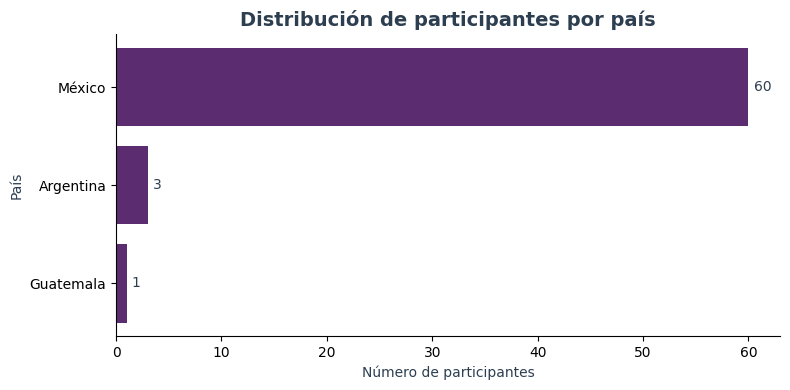

In [ ]:
# Visualización de participantes por país

distribucion_pais_grafica = (
    df['pais']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4))

barras = plt.barh(
    distribucion_pais_grafica.index,
    distribucion_pais_grafica.values,
    color=MORADO_PRINCIPAL
)

plt.title(
    'Distribución de participantes por país',
    fontsize=14,
    fontweight='bold',
    color=GRIS_TEXTO
)

plt.xlabel('Número de participantes', color=GRIS_TEXTO)
plt.ylabel('País', color=GRIS_TEXTO)

# Mostrar número de participantes
for barra in barras:
    plt.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f'{int(barra.get_width())}',
        va='center',
        color=GRIS_TEXTO
    )

# Simplificar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.1.2 Distribución por edad

Se analizó la distribución de edad de las personas participantes mediante estadísticos descriptivos, con el propósito de conocer las características etarias de la muestra.

In [ ]:
# Estadísticos descriptivos de la edad

resumen_edad = df['edad'].describe()

display(
    resumen_edad
    .to_frame(name='valor')
)

,valor
count,62.0
mean,36.129032
std,8.934156
min,21.0
25%,29.25
50%,36.5
75%,41.0
max,62.0


#### Hallazgos

De los 64 participantes, **62 proporcionaron información sobre su edad**, mientras que 2 registros presentaron valores faltantes.

La edad promedio de las personas con información disponible fue de **36.1 años** (DE = 8.9), con una mediana de **36.5 años**. Las edades oscilaron entre **21 y 62 años**.

El 50 % central de las edades se encontró aproximadamente entre **29.3 y 41 años**, de acuerdo con el primer y tercer cuartil.

Estos resultados indican que la muestra está conformada principalmente por personas adultas, aunque existe variabilidad en las edades representadas.

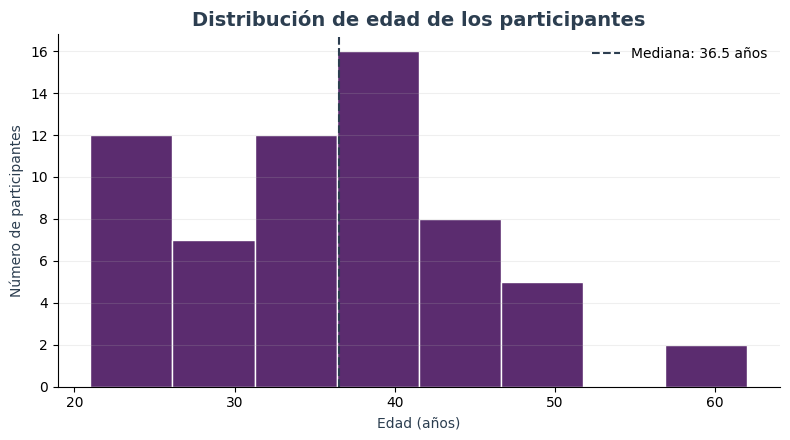

In [ ]:
# Histograma de distribución de edad

plt.figure(figsize=(8, 4.5))

plt.hist(
    df['edad'].dropna(),
    bins=8,
    color=MORADO_PRINCIPAL,
    edgecolor='white'
)

plt.axvline(
    df['edad'].median(),
    linestyle='--',
    linewidth=1.5,
    color=GRIS_TEXTO,
    label=f"Mediana: {df['edad'].median():.1f} años"
)

plt.title(
    'Distribución de edad de los participantes',
    fontsize=14,
    fontweight='bold',
    color=GRIS_TEXTO
)

plt.xlabel('Edad (años)', color=GRIS_TEXTO)
plt.ylabel('Número de participantes', color=GRIS_TEXTO)

plt.legend(frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(
    axis='y',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [ ]:
# Distribución por grupos de edad

distribucion_grupo_edad = (
    df['grupo_edad']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

distribucion_grupo_edad['porcentaje'] = (
    distribucion_grupo_edad['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_grupo_edad)

,participantes,porcentaje
grupo_edad,,
25-39,37,57.8
40+,19,29.7
18-24,6,9.4
Sin dato,2,3.1


#### Distribución por grupos de edad

Al agrupar las edades en intervalos, el grupo con mayor representación fue el de **25 a 39 años**, con 37 participantes (57.8 %), seguido por las personas de **40 años o más**, con 19 participantes (29.7 %). El grupo de **18 a 24 años** estuvo conformado por 6 participantes (9.4 %).

En 2 casos (3.1 %) no se contó con información de edad, por lo que fueron clasificados como **"Sin dato"**.

En conjunto, los resultados muestran que la muestra se concentra principalmente entre los **25 y 39 años**.

### 6.1.3 Escolaridad

Se analizó el nivel de escolaridad reportado por las personas participantes con el propósito de describir la composición educativa de la muestra.

In [ ]:
# Revisar valores originales de escolaridad

conteo_escolaridad = (
    df['escolaridad']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

display(conteo_escolaridad)

print(
    "\nNúmero de categorías diferentes:",
    df['escolaridad'].nunique(dropna=True)
)

,participantes
escolaridad,
Universidad,45
Posgrado,11
Preparatoria,7
Secundaria,1



Número de categorías diferentes: 4


In [ ]:
# Distribución de participantes por escolaridad

distribucion_escolaridad = (
    df['escolaridad']
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_escolaridad['porcentaje'] = (
    distribucion_escolaridad['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_escolaridad)

,participantes,porcentaje
escolaridad,,
Universidad,45,70.3
Posgrado,11,17.2
Preparatoria,7,10.9
Secundaria,1,1.6


#### Hallazgos

La mayoría de las personas participantes reportó estudios de **universidad**, con 45 registros (70.3 %), seguida por quienes reportaron estudios de **posgrado**, con 11 participantes (17.2 %).

En menor proporción se encontraron participantes con estudios de **preparatoria**, con 7 registros (10.9 %), y **secundaria**, con 1 participante (1.6 %).

En conjunto, **87.5 % de la muestra reportó escolaridad universitaria o de posgrado**, lo que indica una alta concentración de participantes con estudios superiores. Esta característica debe considerarse al interpretar los resultados, ya que la composición educativa de la muestra no necesariamente representa la distribución educativa de la población general.

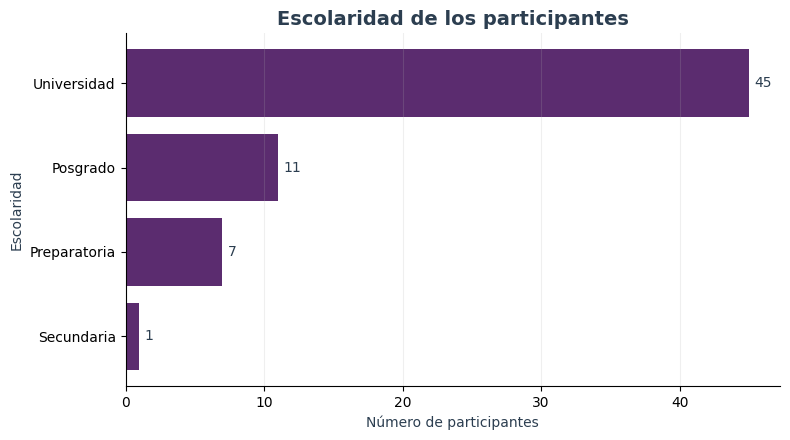

In [ ]:
# Visualización de la escolaridad de los participantes

escolaridad_grafica = (
    df['escolaridad']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

barras = plt.barh(
    escolaridad_grafica.index,
    escolaridad_grafica.values,
    color=MORADO_PRINCIPAL
)

plt.title(
    'Escolaridad de los participantes',
    fontsize=14,
    fontweight='bold',
    color=GRIS_TEXTO
)

plt.xlabel('Número de participantes', color=GRIS_TEXTO)
plt.ylabel('Escolaridad', color=GRIS_TEXTO)

for barra in barras:
    plt.text(
        barra.get_width() + 0.4,
        barra.get_y() + barra.get_height() / 2,
        f'{int(barra.get_width())}',
        va='center',
        color=GRIS_TEXTO
    )

ax = plt.gca()
ax.grid(False)
ax.grid(axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.2 Características relacionadas con el TDAH

### 6.2.1 Diagnóstico formal de TDAH

Se analizó la variable `diagnostico_formal` para conocer la proporción de participantes que reportaron contar con un diagnóstico formal de TDAH y distinguirla de quienes indicaron no tenerlo o únicamente sospechar su presencia.

In [ ]:
# Revisar categorías de diagnóstico formal

conteo_diagnostico = (
    df['diagnostico_formal']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

display(conteo_diagnostico)

print(
    "\nNúmero de categorías diferentes:",
    df['diagnostico_formal'].nunique(dropna=True)
)

,participantes
diagnostico_formal,
Sí,39
"No, pero sospecho que sí",18
No,7



Número de categorías diferentes: 3


In [ ]:
# Distribución del diagnóstico formal de TDAH

distribucion_diagnostico = (
    df['diagnostico_formal']
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_diagnostico['porcentaje'] = (
    distribucion_diagnostico['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_diagnostico)

,participantes,porcentaje
diagnostico_formal,,
Sí,39,60.9
"No, pero sospecho que sí",18,28.1
No,7,10.9


#### Hallazgos

De los 64 participantes, **39 personas (60.9 %)** reportaron contar con un diagnóstico formal de TDAH. Por otra parte, **18 participantes (28.1 %)** indicaron no contar con un diagnóstico formal, pero sospechar que podrían tener TDAH, mientras que **7 personas (10.9 %)** señalaron no tener un diagnóstico.

Por lo tanto, aunque la mayoría de la muestra reportó un diagnóstico formal, una proporción considerable corresponde a personas que únicamente sospechan presentar TDAH. Esta distinción se conservará en los análisis posteriores para evitar equiparar la sospecha de TDAH con un diagnóstico formal.

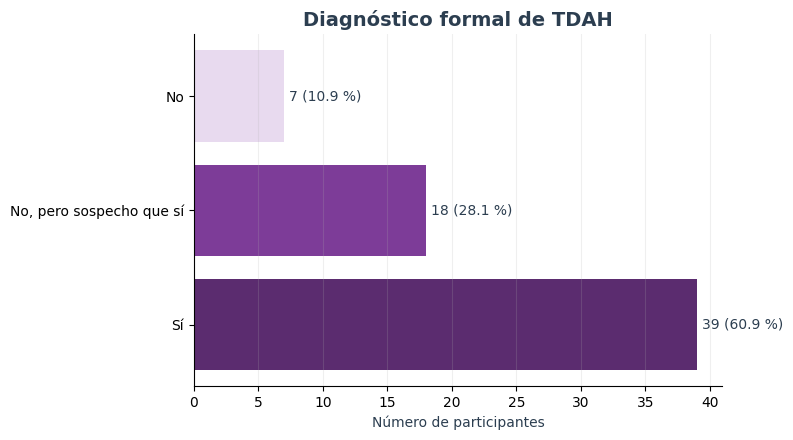

In [ ]:
# Visualización del diagnóstico formal de TDAH

orden_diagnostico = [
    'Sí',
    'No, pero sospecho que sí',
    'No'
]

datos_diagnostico = (
    df['diagnostico_formal']
    .value_counts()
    .reindex(orden_diagnostico)
)

colores = [
    MORADO_PRINCIPAL,
    MORADO_SECUNDARIO,
    LAVANDA
]

plt.figure(figsize=(8, 4.5))

barras = plt.barh(
    datos_diagnostico.index,
    datos_diagnostico.values,
    color=colores
)

plt.title(
    'Diagnóstico formal de TDAH',
    fontsize=14,
    fontweight='bold',
    color=GRIS_TEXTO
)

plt.xlabel('Número de participantes', color=GRIS_TEXTO)
plt.ylabel('')

# Mostrar frecuencia y porcentaje
for barra, valor in zip(barras, datos_diagnostico.values):
    porcentaje = valor / len(df) * 100

    plt.text(
        barra.get_width() + 0.4,
        barra.get_y() + barra.get_height() / 2,
        f'{valor} ({porcentaje:.1f} %)',
        va='center',
        color=GRIS_TEXTO
    )

ax = plt.gca()
ax.grid(False)
ax.grid(axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.2.2 Tipo de TDAH

Se analizó la variable `tipo_tdah` con el propósito de identificar la distribución de los tipos o presentaciones de TDAH reportados por las personas participantes.

Antes de realizar el análisis, se revisaron las categorías originales de la variable para identificar posibles diferencias de escritura, respuestas que requirieran estandarización y valores faltantes.

Debido a que la información sobre el tipo de TDAH puede depender de la existencia de un diagnóstico previo, primero se examinará la distribución de las respuestas y su relación con la información disponible en `diagnostico_formal`. A partir de esta revisión se determinará la población adecuada para calcular las frecuencias y porcentajes.

In [ ]:
# Revisar categorías de tipo de TDAH

conteo_tipo_tdah = (
    df['tipo_tdah']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

display(conteo_tipo_tdah)

print(
    "\nNúmero de categorías diferentes:",
    df['tipo_tdah'].nunique(dropna=False)
)

print(
    "Valores nulos:",
    df['tipo_tdah'].isna().sum()
)

,participantes
tipo_tdah,
Combinado,28
No sé,17
Inatento,13
Hiperactivo / Impulsivo,6



Número de categorías diferentes: 4
Valores nulos: 0


In [ ]:
# Distribución del tipo de TDAH

distribucion_tipo_tdah = (
    df['tipo_tdah']
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_tipo_tdah['porcentaje'] = (
    distribucion_tipo_tdah['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_tipo_tdah)

,participantes,porcentaje
tipo_tdah,,
Combinado,28,43.8
No sé,17,26.6
Inatento,13,20.3
Hiperactivo / Impulsivo,6,9.4


In [ ]:
# Relación entre diagnóstico formal y tipo de TDAH

cruce_diagnostico_tipo = pd.crosstab(
    df['diagnostico_formal'],
    df['tipo_tdah'],
    margins=True,
    margins_name='Total'
)

display(cruce_diagnostico_tipo)

tipo_tdah,Combinado,Hiperactivo / Impulsivo,Inatento,No sé,Total
diagnostico_formal,,,,,
No,4,0,0,3,7
"No, pero sospecho que sí",5,0,1,12,18
Sí,19,6,12,2,39
Total,28,6,13,17,64


In [ ]:
# Distribución del tipo de TDAH entre participantes con diagnóstico formal

tipo_tdah_diagnosticados = df.loc[
    df['diagnostico_formal'] == 'Sí',
    'tipo_tdah'
]

distribucion_tipo_diagnosticados = (
    tipo_tdah_diagnosticados
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_tipo_diagnosticados['porcentaje'] = (
    distribucion_tipo_diagnosticados['participantes']
    / len(tipo_tdah_diagnosticados)
    * 100
).round(1)

display(distribucion_tipo_diagnosticados)

print(
    "\nParticipantes con diagnóstico formal:",
    len(tipo_tdah_diagnosticados)
)

,participantes,porcentaje
tipo_tdah,,
Combinado,19,48.7
Inatento,12,30.8
Hiperactivo / Impulsivo,6,15.4
No sé,2,5.1



Participantes con diagnóstico formal: 39


#### Hallazgos sobre el tipo de TDAH

Debido a que la variable `tipo_tdah` también fue respondida por participantes que indicaron no contar con un diagnóstico formal, el análisis principal de esta variable se realizó únicamente entre las **39 personas que reportaron contar con diagnóstico formal de TDAH**.

Dentro de este grupo, el tipo de TDAH reportado con mayor frecuencia fue el **combinado**, con **19 participantes (48.7 %)**, seguido del **inatento**, con **12 participantes (30.8 %)**, y el **hiperactivo / impulsivo**, con **6 participantes (15.4 %)**. Además, **2 participantes (5.1 %)** indicaron no conocer su tipo de TDAH.

Aunque algunos participantes sin diagnóstico formal seleccionaron un tipo de TDAH, estas respuestas no se incluyeron en esta distribución para evitar interpretar una identificación o percepción personal como un diagnóstico clínico.

Los resultados corresponden a los tipos de TDAH reportados por los participantes y no representan una verificación clínica independiente.

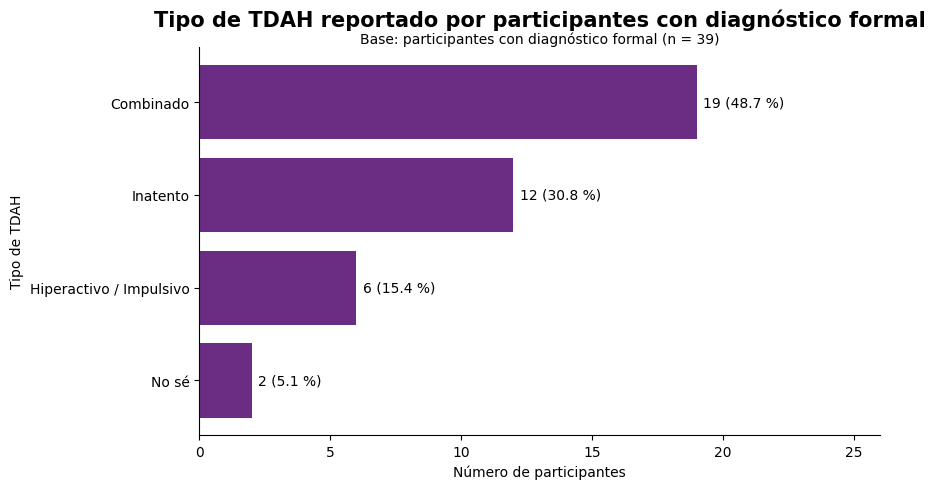

In [ ]:
# Gráfica de distribución del tipo de TDAH
# Base: participantes con diagnóstico formal (n = 39)

# Ordenar para facilitar la lectura
grafica_tipo_tdah = (
    distribucion_tipo_diagnosticados
    .sort_values('participantes', ascending=True)
)

# Color principal del portafolio
morado = '#6B2D84'

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.barh(
    grafica_tipo_tdah.index,
    grafica_tipo_tdah['participantes'],
    color=morado
)

# Mostrar frecuencia y porcentaje al final de cada barra
for barra, participantes, porcentaje in zip(
    barras,
    grafica_tipo_tdah['participantes'],
    grafica_tipo_tdah['porcentaje']
):
    ax.text(
        barra.get_width() + 0.25,
        barra.get_y() + barra.get_height() / 2,
        f'{participantes} ({porcentaje:.1f} %)',
        va='center',
        fontsize=10
    )

ax.set_title(
    'Tipo de TDAH reportado por participantes con diagnóstico formal',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Número de participantes')
ax.set_ylabel('Tipo de TDAH')

# Ampliar eje para dejar espacio a las etiquetas
ax.set_xlim(
    0,
    grafica_tipo_tdah['participantes'].max() + 7
)

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(
    0.5, 1.01,
    'Base: participantes con diagnóstico formal (n = 39)',
    transform=ax.transAxes,
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

### 6.2.3 Edad de diagnóstico

Se analizó la variable `edad_diagnostico_limpia` con el propósito de describir la edad a la que las personas participantes con diagnóstico formal de TDAH reportaron haber recibido dicho diagnóstico.

Esta variable fue generada durante el proceso de limpieza a partir de `edad_diagnostico`, conservando únicamente aquellas respuestas en las que fue posible identificar una edad específica. Las respuestas que no proporcionaban una edad cuantificable se mantuvieron como valores faltantes (`NA`) y no fueron imputadas.

Aunque se identificaron 48 registros con una edad cuantificable en la muestra completa, 10 correspondían a participantes que no reportaron contar con un diagnóstico formal de TDAH. Para evitar interpretar estas respuestas como edades de un diagnóstico clínico, el análisis se restringió a las personas que indicaron contar con diagnóstico formal.

De las 39 personas con diagnóstico formal, **38 proporcionaron una edad de diagnóstico cuantificable**, por lo que este grupo constituye la base del análisis de la edad de diagnóstico (**n = 38**).

In [ ]:
# Validar edad de diagnóstico según diagnóstico formal

validacion_edad_diagnostico = pd.crosstab(
    df['diagnostico_formal'],
    df['edad_diagnostico_limpia'].notna(),
    margins=True,
    margins_name='Total'
)

# Renombrar columnas para facilitar interpretación
validacion_edad_diagnostico = validacion_edad_diagnostico.rename(
    columns={
        False: 'Sin edad cuantificable',
        True: 'Con edad cuantificable'
    }
)

display(validacion_edad_diagnostico)

edad_diagnostico_limpia,Sin edad cuantificable,Con edad cuantificable,Total
diagnostico_formal,,,
No,5,2,7
"No, pero sospecho que sí",10,8,18
Sí,1,38,39
Total,16,48,64


In [ ]:
# Seleccionar participantes con diagnóstico formal
# y edad de diagnóstico cuantificable

edad_diagnostico_formal = df.loc[
    (df['diagnostico_formal'] == 'Sí') &
    (df['edad_diagnostico_limpia'].notna()),
    'edad_diagnostico_limpia'
]

print(
    "Participantes incluidos en el análisis:",
    len(edad_diagnostico_formal)
)

display(
    edad_diagnostico_formal
    .describe()
    .to_frame(name='valor')
)

Participantes incluidos en el análisis: 38


,valor
count,38.0
mean,33.526316
std,8.620331
min,20.0
25%,26.0
50%,33.5
75%,39.0
max,50.0


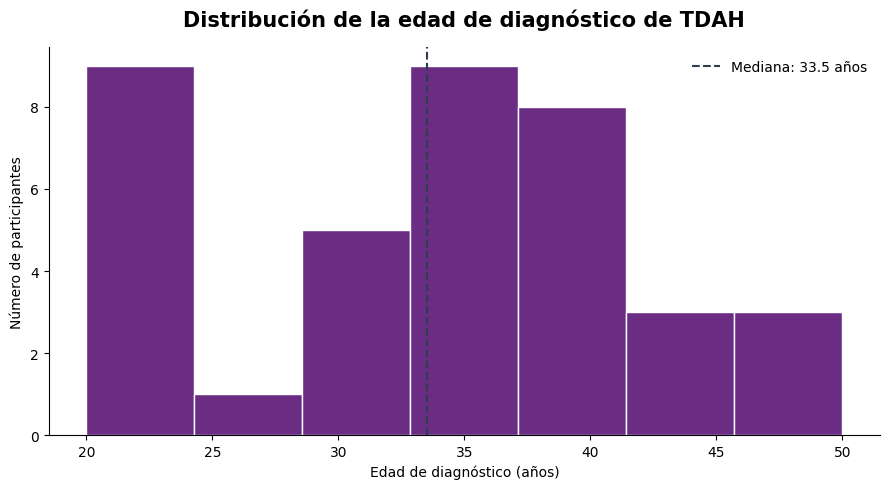

In [ ]:
# Distribución de la edad de diagnóstico
# Base: participantes con diagnóstico formal y edad cuantificable (n = 38)

mediana_diagnostico = edad_diagnostico_formal.median()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    edad_diagnostico_formal,
    bins=7,
    color='#6B2D84',
    edgecolor='white'
)

# Línea de la mediana
ax.axvline(
    mediana_diagnostico,
    linestyle='--',
    linewidth=1.5,
    color=GRIS_TEXTO,
    label=f'Mediana: {mediana_diagnostico:.1f} años'
)

ax.set_title(
    'Distribución de la edad de diagnóstico de TDAH',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Edad de diagnóstico (años)')
ax.set_ylabel('Número de participantes')

ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos sobre la edad de diagnóstico

El análisis de la edad de diagnóstico se realizó sobre **38 participantes con diagnóstico formal de TDAH y una edad de diagnóstico cuantificable**.

La edad media reportada al momento del diagnóstico fue de **33.5 años**, con una mediana también de **33.5 años** y una desviación estándar de **8.6 años**. Las edades de diagnóstico oscilaron entre los **20 y los 50 años**.

El 50 % central de las edades de diagnóstico se encontró entre los **26 y 39 años**, lo que indica que una proporción importante de los diagnósticos reportados ocurrió durante la edad adulta.

La distribución muestra diagnósticos en diferentes etapas de la adultez, con presencia tanto de diagnósticos alrededor de los primeros años de los 20 como de diagnósticos realizados durante las décadas de los 30 y 40 años.

Estos resultados describen únicamente las edades de diagnóstico reportadas por los participantes y no constituyen una verificación independiente de la información clínica.

## 6.3 Situación laboral

### 6.3.1 Situación laboral actual
En este apartado se analiza la situación laboral de las personas participantes con el propósito de describir su participación actual en el mercado de trabajo y las principales modalidades laborales reportadas.

Para ello se utilizan las variables `trabaja_actualmente` y `modalidad_trabajo_limpia`. Esta última fue generada durante el proceso de limpieza y preparación de los datos para estandarizar las diferentes respuestas registradas originalmente en `modalidad_trabajo`, considerando también la información proporcionada en `trabaja_actualmente`.

El análisis se realizará mediante frecuencias y porcentajes, conservando las variables originales para mantener la trazabilidad de la información.

In [ ]:
# Distribución de la situación laboral actual

distribucion_trabajo_actual = (
    df['trabaja_actualmente']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

distribucion_trabajo_actual['porcentaje'] = (
    distribucion_trabajo_actual['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_trabajo_actual)

print(
    "\nNúmero de categorías diferentes:",
    df['trabaja_actualmente'].nunique(dropna=False)
)

print(
    "Valores nulos:",
    df['trabaja_actualmente'].isna().sum()
)

,participantes,porcentaje
trabaja_actualmente,,
Sí,37,57.8
Trabajo por cuenta propia,14,21.9
No,7,10.9
Buscando empleo,6,9.4



Número de categorías diferentes: 4
Valores nulos: 0


#### Hallazgos sobre la situación laboral actual

De las **64 personas participantes**, **37 (57.8 %)** indicaron que actualmente trabajan, **14 (21.9 %)** reportaron trabajar por cuenta propia, **7 (10.9 %)** señalaron que no trabajan y **6 (9.4 %)** indicaron encontrarse buscando empleo.

Con el propósito de facilitar los análisis comparativos posteriores, se creó la variable derivada `situacion_laboral`, agrupando las respuestas en dos categorías generales:

- **Trabaja:** incluye a quienes respondieron `Sí` y `Trabajo por cuenta propia`.
- **No trabaja:** incluye a quienes respondieron `No` y `Buscando empleo`.

A partir de esta clasificación, **51 participantes (79.7 %)** fueron clasificados como personas que actualmente trabajan y **13 (20.3 %)** como personas que actualmente no trabajan.

La variable original `trabaja_actualmente` se conservó sin modificaciones para mantener el nivel de detalle y la trazabilidad de las respuestas originales. La variable `situacion_laboral` se utilizará únicamente como una agrupación derivada para facilitar determinados análisis comparativos.

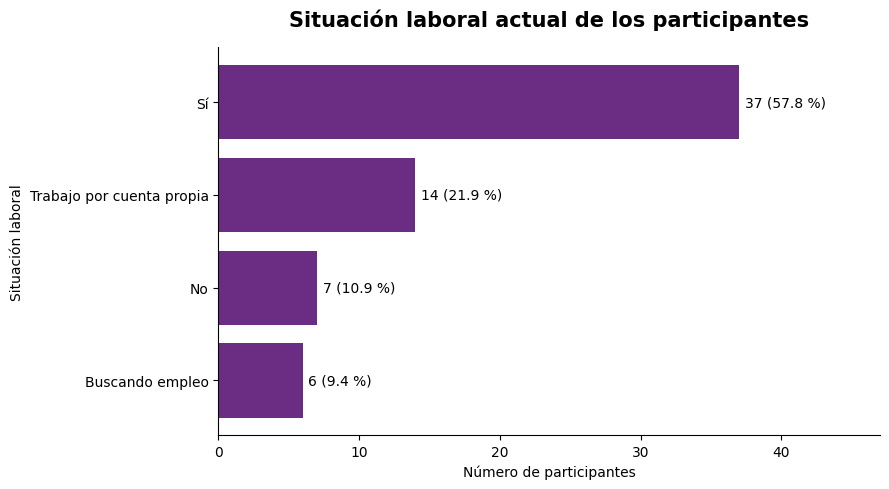

In [ ]:
# Gráfica de situación laboral actual

grafica_trabajo = (
    distribucion_trabajo_actual
    .sort_values('participantes', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.barh(
    grafica_trabajo.index,
    grafica_trabajo['participantes'],
    color='#6B2D84'
)

for barra, participantes, porcentaje in zip(
    barras,
    grafica_trabajo['participantes'],
    grafica_trabajo['porcentaje']
):
    ax.text(
        barra.get_width() + 0.4,
        barra.get_y() + barra.get_height() / 2,
        f'{participantes} ({porcentaje:.1f} %)',
        va='center',
        fontsize=10
    )

ax.set_title(
    'Situación laboral actual de los participantes',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Número de participantes')
ax.set_ylabel('Situación laboral')

ax.set_xlim(
    0,
    grafica_trabajo['participantes'].max() + 10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.3.2 Modalidad de trabajo

Se analizó la variable `modalidad_trabajo_limpia` con el propósito de describir las principales modalidades laborales reportadas por las personas participantes.

Esta variable fue generada durante el proceso de limpieza y preparación de los datos a partir de `modalidad_trabajo`, considerando también la información registrada en `trabaja_actualmente`. La estandarización permitió agrupar respuestas equivalentes y diferenciar a las personas que no se encontraban trabajando al momento de responder la encuesta.

Para el análisis se calcularán las frecuencias y porcentajes correspondientes a cada modalidad, conservando la variable original para mantener la trazabilidad de las respuestas.

In [ ]:
# Distribución de la modalidad de trabajo

distribucion_modalidad = (
    df['modalidad_trabajo_limpia']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

distribucion_modalidad['porcentaje'] = (
    distribucion_modalidad['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_modalidad)

print(
    "\nNúmero de categorías diferentes:",
    df['modalidad_trabajo_limpia'].nunique(dropna=False)
)

print(
    "Valores nulos:",
    df['modalidad_trabajo_limpia'].isna().sum()
)

,participantes,porcentaje
modalidad_trabajo_limpia,,
Tiempo completo,26,40.6
Freelance / Independiente,15,23.4
Informal,8,12.5
No trabaja,7,10.9
Medio tiempo,4,6.2
Buscando empleo,2,3.1
Otra,2,3.1



Número de categorías diferentes: 7
Valores nulos: 0


In [ ]:
# Validar modalidad de trabajo según situación laboral

cruce_situacion_modalidad = pd.crosstab(
    df['situacion_laboral'],
    df['modalidad_trabajo_limpia'],
    margins=True,
    margins_name='Total'
)

display(cruce_situacion_modalidad)

modalidad_trabajo_limpia,Buscando empleo,Freelance / Independiente,Informal,Medio tiempo,No trabaja,Otra,Tiempo completo,Total
situacion_laboral,,,,,,,,
No trabaja,2,2,1,0,7,0,1,13
Trabaja,0,13,7,4,0,2,25,51
Total,2,15,8,4,7,2,26,64


In [ ]:
# Revisar inconsistencias entre situación laboral y modalidad de trabajo

inconsistencias_laborales = df.loc[
    (df['situacion_laboral'] == 'No trabaja') &
    (~df['modalidad_trabajo_limpia'].isin([
        'No trabaja',
        'Buscando empleo'
    ])),
    [
        'trabaja_actualmente',
        'modalidad_trabajo',
        'modalidad_trabajo_limpia'
    ]
].copy()

display(inconsistencias_laborales)

print(
    "\nNúmero de casos a revisar:",
    len(inconsistencias_laborales)
)

,trabaja_actualmente,modalidad_trabajo,modalidad_trabajo_limpia
2,Buscando empleo,Tiempo completo,Tiempo completo
20,Buscando empleo,Freelance / Independiente,Freelance / Independiente
21,Buscando empleo,Informal,Informal
29,Buscando empleo,Freelance / Independiente,Freelance / Independiente



Número de casos a revisar: 4


In [ ]:
# Validar modalidad de quienes respondieron "No" en trabaja_actualmente

revision_no_trabaja = df.loc[
    df['trabaja_actualmente'] == 'No',
    [
        'trabaja_actualmente',
        'modalidad_trabajo',
        'modalidad_trabajo_limpia'
    ]
].copy()

display(revision_no_trabaja)

print(
    "\nNúmero de participantes:",
    len(revision_no_trabaja)
)

,trabaja_actualmente,modalidad_trabajo,modalidad_trabajo_limpia
5,No,Pensionada,No trabaja
6,No,Jubilado,No trabaja
14,No,No trabajo,No trabaja
24,No,Ama de casa,No trabaja
35,No,Freelance / Independiente,No trabaja
37,No,Informal,No trabaja
57,No,No tengo,No trabaja



Número de participantes: 7


**Tratamiento de la modalidad de trabajo**

La variable `modalidad_trabajo` presentó algunas inconsistencias respecto a `trabaja_actualmente`, por lo que se creó la variable derivada `modalidad_trabajo_limpia` para facilitar su análisis sin modificar las respuestas originales.

Para las personas que indicaron `No` en `trabaja_actualmente`, la modalidad se clasificó como **No trabaja**, independientemente de la respuesta registrada en `modalidad_trabajo`. Esta decisión permitió utilizar la situación laboral declarada explícitamente como criterio principal de clasificación.

Durante la validación se identificaron también participantes que señalaron estar **Buscando empleo** y, al mismo tiempo, reportaron una modalidad de trabajo como tiempo completo, freelance/independiente o informal. Estas respuestas se conservaron sin corregir, ya que ambas situaciones pueden coexistir o reflejar distintas interpretaciones de las preguntas.

Por lo tanto, `trabaja_actualmente` y `modalidad_trabajo_limpia` se consideran variables relacionadas pero conceptualmente distintas, y las respuestas originales se conservaron para mantener la trazabilidad del proceso de limpieza.

In [ ]:
# Distribución de modalidad de trabajo

distribucion_modalidad = (
    df['modalidad_trabajo_limpia']
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_modalidad['porcentaje'] = (
    distribucion_modalidad['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_modalidad)

print(
    "\nTotal de participantes:",
    distribucion_modalidad['participantes'].sum()
)

,participantes,porcentaje
modalidad_trabajo_limpia,,
Tiempo completo,26,40.6
Freelance / Independiente,15,23.4
Informal,8,12.5
No trabaja,7,10.9
Medio tiempo,4,6.2
Buscando empleo,2,3.1
Otra,2,3.1



Total de participantes: 64


**Hallazgos sobre la modalidad de trabajo**

La modalidad de trabajo más frecuente en la muestra fue **tiempo completo**, reportada por 26 participantes (40.6 %). En segundo lugar se encontró el trabajo **freelance o independiente**, con 15 participantes (23.4 %), seguido del trabajo **informal**, con 8 participantes (12.5 %).

Por otra parte, 7 participantes (10.9 %) fueron clasificados en la categoría **No trabaja**, mientras que 4 (6.2 %) reportaron trabajar **medio tiempo**. Las categorías **Buscando empleo** y **Otra** estuvieron representadas por 2 participantes cada una (3.1 %).

En conjunto, los resultados muestran una diversidad de modalidades laborales dentro de la muestra, aunque el trabajo de tiempo completo concentra la mayor proporción de participantes.

La variable `modalidad_trabajo_limpia` se analiza de manera independiente de `trabaja_actualmente`, debido a que durante la limpieza se identificaron algunos casos en los que las respuestas de ambas variables no coincidían completamente. Las respuestas originales se conservaron y las decisiones de estandarización fueron documentadas durante el proceso de preparación de los datos.

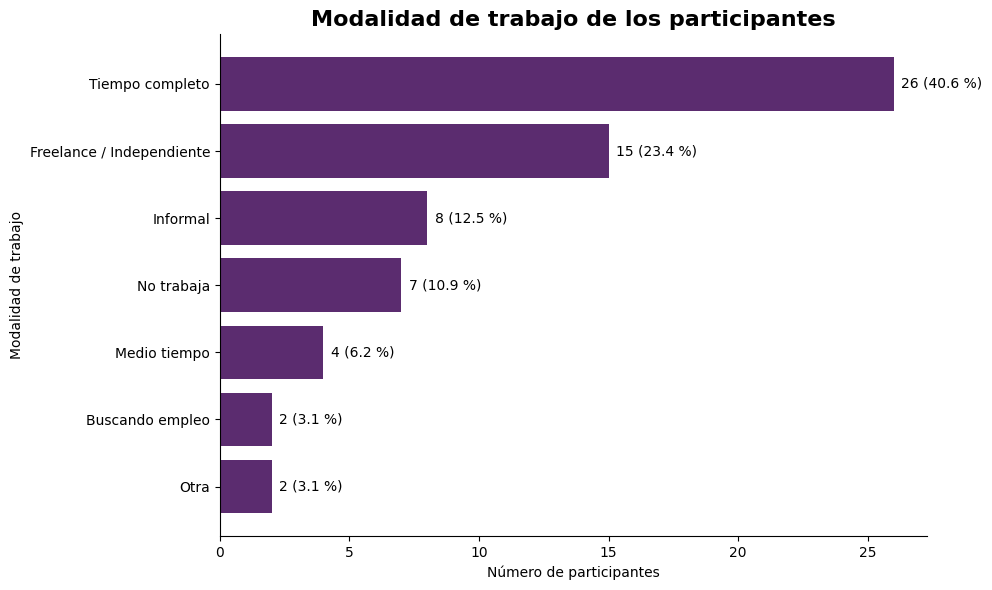

In [ ]:
# Gráfica de modalidad de trabajo

datos_grafica = distribucion_modalidad.sort_values(
    'participantes',
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    datos_grafica.index,
    datos_grafica['participantes'],
    color=MORADO_PRINCIPAL
)

# Etiquetas con frecuencia y porcentaje
for barra, participantes, porcentaje in zip(
    barras,
    datos_grafica['participantes'],
    datos_grafica['porcentaje']
):
    ax.text(
        barra.get_width() + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f'{participantes} ({porcentaje:.1f} %)',
        va='center'
    )

ax.set_title(
    'Modalidad de trabajo de los participantes',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de participantes')
ax.set_ylabel('Modalidad de trabajo')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.3.3 Dificultades laborales

En este apartado se analiza la presencia y naturaleza de las dificultades laborales reportadas por los participantes.

Debido a que la variable original `dificultades_laborales` contiene respuestas abiertas, el análisis se realiza en diferentes niveles. Primero se examina la proporción de participantes que reportó alguna dificultad mediante la variable derivada `reporta_dificultad`. Posteriormente, se considera el nivel de información disponible en las respuestas y se analizan las categorías temáticas identificadas durante el proceso de codificación.

Las categorías temáticas no son mutuamente excluyentes, ya que una misma respuesta puede mencionar más de una dificultad. Por esta razón, en el análisis de categorías la suma de los porcentajes puede superar el 100 %.

In [ ]:
# Distribución de participantes que reportaron dificultades laborales

distribucion_dificultad = (
    df['reporta_dificultad']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

distribucion_dificultad['porcentaje'] = (
    distribucion_dificultad['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_dificultad)

print(
    "\nTotal de participantes:",
    distribucion_dificultad['participantes'].sum()
)

,participantes,porcentaje
reporta_dificultad,,
Sí,58,90.6
No,5,7.8
No determinado,1,1.6



Total de participantes: 64


**Dificultades laborales reportadas**

De los 64 participantes, **58 (90.6 %)** reportaron haber experimentado alguna dificultad laboral, mientras que **5 (7.8 %)** indicaron no haber presentado dificultades. En **1 caso (1.6 %)** no fue posible determinarlo con suficiente certeza a partir de la respuesta proporcionada.

Estos resultados muestran que las dificultades laborales fueron reportadas por una amplia mayoría de los participantes de la muestra. Sin embargo, este resultado debe interpretarse únicamente en el contexto de las personas participantes y no como una estimación de la prevalencia de dificultades laborales entre la población general con TDAH.

La identificación de una dificultad en este primer nivel no implica necesariamente que la respuesta proporcionara información suficiente para determinar qué tipo de dificultad experimentó la persona. Por esta razón, posteriormente se analiza por separado el nivel de detalle de las respuestas y las categorías temáticas identificadas.

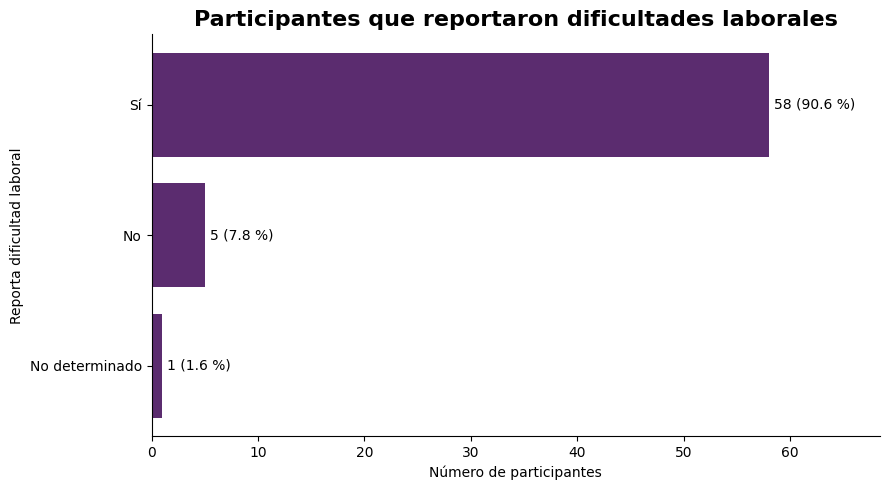

In [ ]:
# Gráfica de dificultades laborales reportadas

datos_grafica = distribucion_dificultad.sort_values(
    'participantes',
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.barh(
    datos_grafica.index,
    datos_grafica['participantes'],
    color=MORADO_PRINCIPAL
)

# Etiquetas con frecuencia y porcentaje
for barra, participantes, porcentaje in zip(
    barras,
    datos_grafica['participantes'],
    datos_grafica['porcentaje']
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f'{participantes} ({porcentaje:.1f} %)',
        va='center'
    )

ax.set_title(
    'Participantes que reportaron dificultades laborales',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de participantes')
ax.set_ylabel('Reporta dificultad laboral')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Espacio adicional para las etiquetas
ax.set_xlim(0, datos_grafica['participantes'].max() * 1.18)

plt.tight_layout()
plt.show()

In [ ]:
# Distribución del nivel de detalle de las dificultades laborales

distribucion_detalle = (
    df['detalle_dificultad']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

distribucion_detalle['porcentaje'] = (
    distribucion_detalle['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_detalle)

print(
    "\nTotal de participantes:",
    distribucion_detalle['participantes'].sum()
)

,participantes,porcentaje
detalle_dificultad,,
Con detalle temático,37,57.8
Sin detalle suficiente,22,34.4
Sin dificultad reportada,5,7.8



Total de participantes: 64


**Nivel de detalle de las respuestas**

Aunque 58 participantes indicaron haber experimentado alguna dificultad laboral, no todas las respuestas proporcionaron información suficiente para identificar el tipo de dificultad reportada.

De los 64 participantes, **37 (57.8 %)** proporcionaron una respuesta con suficiente detalle para realizar la clasificación temática, mientras que **22 (34.4 %)** presentaron respuestas sin detalle suficiente. Los **5 participantes restantes (7.8 %)** indicaron no haber experimentado dificultades laborales.

Por esta razón, el análisis de las categorías temáticas se realiza principalmente sobre las **37 respuestas con detalle suficiente**. Una misma respuesta puede contener más de una categoría de dificultad, por lo que las categorías no son mutuamente excluyentes y sus porcentajes no necesariamente suman 100 %.

Para facilitar la interpretación, en el análisis posterior se presentan tanto las frecuencias absolutas como el porcentaje respecto a las 37 respuestas con detalle temático.

In [ ]:
# Frecuencia de categorías temáticas de dificultades laborales

n_con_detalle = (
    df['detalle_dificultad'] == 'Con detalle temático'
).sum()

resumen_dificultades = (
    df[columnas_dificultades]
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='participantes')
)

# Porcentaje respecto a toda la muestra
resumen_dificultades['porcentaje_muestra'] = (
    resumen_dificultades['participantes']
    / len(df)
    * 100
).round(1)

# Porcentaje respecto a las respuestas con detalle temático
resumen_dificultades['porcentaje_con_detalle'] = (
    resumen_dificultades['participantes']
    / n_con_detalle
    * 100
).round(1)

display(resumen_dificultades)

print(f"\nParticipantes totales: {len(df)}")
print(f"Respuestas con detalle temático: {n_con_detalle}")

,participantes,porcentaje_muestra,porcentaje_con_detalle
gestion_tiempo_puntualidad,12,18.8,32.4
atencion_concentracion,9,14.1,24.3
organizacion_planificacion,8,12.5,21.6
regulacion_emocional_estres,7,10.9,18.9
motivacion_aburrimiento,7,10.9,18.9
memoria_seguimiento,5,7.8,13.5
comunicacion_relaciones,5,7.8,13.5
comprension_instrucciones,3,4.7,8.1
sobrecarga_agotamiento,2,3.1,5.4
impulsividad,1,1.6,2.7



Participantes totales: 64
Respuestas con detalle temático: 37


**Categorías de dificultades laborales**

Entre las **37 respuestas con detalle temático suficiente**, la dificultad identificada con mayor frecuencia fue **gestión del tiempo y puntualidad**, presente en 12 participantes (32.4 % de las respuestas con detalle). Le siguieron **atención y concentración**, con 9 participantes (24.3 %), y **organización y planificación**, con 8 participantes (21.6 %).

Las dificultades relacionadas con **regulación emocional y estrés** y **motivación y aburrimiento** fueron identificadas en 7 participantes cada una (18.9 %). Por su parte, **memoria y seguimiento** y **comunicación y relaciones laborales** estuvieron presentes en 5 participantes cada una (13.5 %).

Con menor frecuencia se identificaron dificultades relacionadas con **comprensión de instrucciones**, con 3 participantes (8.1 %); **sobrecarga y agotamiento**, con 2 (5.4 %); e **impulsividad** y **resolución de problemas**, con 1 participante cada una (2.7 %).

Estos porcentajes utilizan como referencia las **37 respuestas con detalle temático**, ya que únicamente estas proporcionaron información suficiente para identificar dificultades específicas. Como una misma respuesta podía clasificarse en más de una categoría, las categorías no son mutuamente excluyentes y sus porcentajes no deben sumar 100 %.

De manera complementaria, la tabla presenta el porcentaje que representa cada categoría respecto a la muestra completa de 64 participantes, permitiendo distinguir entre la frecuencia observada en toda la muestra y la frecuencia entre las respuestas que pudieron ser clasificadas temáticamente.

Los resultados corresponden exclusivamente a la muestra analizada y las categorías fueron construidas de manera exploratoria a partir de las respuestas abiertas, por lo que no deben interpretarse como una clasificación clínica ni generalizarse a toda la población con TDAH.

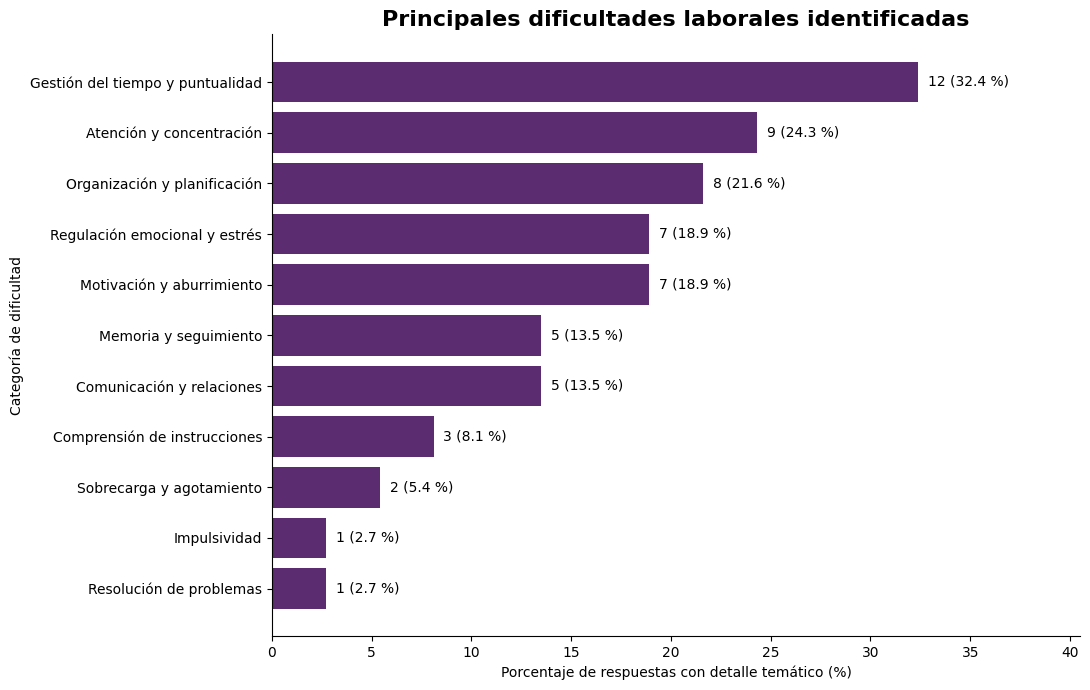

In [ ]:
# Gráfica de categorías de dificultades laborales

# Nombres más legibles para la gráfica
nombres_categorias = {
    'gestion_tiempo_puntualidad': 'Gestión del tiempo y puntualidad',
    'atencion_concentracion': 'Atención y concentración',
    'organizacion_planificacion': 'Organización y planificación',
    'regulacion_emocional_estres': 'Regulación emocional y estrés',
    'motivacion_aburrimiento': 'Motivación y aburrimiento',
    'memoria_seguimiento': 'Memoria y seguimiento',
    'comunicacion_relaciones': 'Comunicación y relaciones',
    'comprension_instrucciones': 'Comprensión de instrucciones',
    'sobrecarga_agotamiento': 'Sobrecarga y agotamiento',
    'impulsividad': 'Impulsividad',
    'resolucion_problemas': 'Resolución de problemas'
}

datos_grafica = resumen_dificultades.copy()

datos_grafica['categoria'] = (
    datos_grafica.index.map(nombres_categorias)
)

datos_grafica = datos_grafica.sort_values(
    'porcentaje_con_detalle',
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    datos_grafica['categoria'],
    datos_grafica['porcentaje_con_detalle'],
    color=MORADO_PRINCIPAL
)

# Etiquetas: participantes + porcentaje
for barra, participantes, porcentaje in zip(
    barras,
    datos_grafica['participantes'],
    datos_grafica['porcentaje_con_detalle']
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f'{participantes} ({porcentaje:.1f} %)',
        va='center'
    )

ax.set_title(
    'Principales dificultades laborales identificadas',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Porcentaje de respuestas con detalle temático (%)'
)

ax.set_ylabel('Categoría de dificultad')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(
    0,
    datos_grafica['porcentaje_con_detalle'].max() * 1.25
)

plt.tight_layout()
plt.show()

In [ ]:
# Número de categorías de dificultad por participante
# Solo respuestas con detalle temático

distribucion_numero_categorias = (
    df.loc[
        df['detalle_dificultad'] == 'Con detalle temático',
        'numero_categorias_dificultad'
    ]
    .value_counts()
    .sort_index()
    .rename_axis('numero_categorias')
    .to_frame(name='participantes')
)

distribucion_numero_categorias['porcentaje'] = (
    distribucion_numero_categorias['participantes']
    / distribucion_numero_categorias['participantes'].sum()
    * 100
).round(1)

display(distribucion_numero_categorias)

print(
    "\nParticipantes con detalle temático:",
    distribucion_numero_categorias['participantes'].sum()
)

,participantes,porcentaje
numero_categorias,,
1,21,56.8
2,10,27.0
3,5,13.5
4,1,2.7



Participantes con detalle temático: 37


**Número de categorías de dificultad por participante**

Entre los **37 participantes cuyas respuestas contenían suficiente detalle para realizar la clasificación temática**, 21 (56.8 %) presentaron dificultades correspondientes a una sola categoría, mientras que 10 (27.0 %) mencionaron dificultades asociadas con dos categorías.

Además, 5 participantes (13.5 %) presentaron dificultades clasificadas en tres categorías y 1 participante (2.7 %) en cuatro categorías.

En conjunto, **16 de los 37 participantes (43.2 %)** con respuestas clasificables reportaron dificultades asociadas con **dos o más categorías temáticas**. Esto muestra que, en una proporción importante de las respuestas analizadas, las dificultades laborales descritas no se limitaron a un solo ámbito.

Este carácter multietiqueta de la clasificación explica por qué los porcentajes correspondientes a las categorías de dificultades laborales no son mutuamente excluyentes y no deben sumar 100 %.

### 6.3.4 Apoyos laborales

En este apartado se analizan las respuestas proporcionadas por los participantes respecto a los apoyos laborales relacionados con el TDAH.

Debido a que `apoyos_laborales` corresponde a una variable de respuesta abierta, primero se revisan las respuestas originales para identificar patrones recurrentes y determinar si es pertinente realizar una clasificación temática.

Las respuestas originales se conservan sin modificaciones con el propósito de mantener la trazabilidad de la información proporcionada por los participantes.

In [ ]:
# Explorar respuestas originales sobre apoyos laborales

print("Número de registros:", len(df))

print(
    "Valores nulos:",
    df['apoyos_laborales'].isna().sum()
)

print(
    "Respuestas diferentes:",
    df['apoyos_laborales'].nunique(dropna=True)
)

display(
    df['apoyos_laborales']
    .value_counts(dropna=False)
    .to_frame(name='participantes')
)

Número de registros: 64
Valores nulos: 0
Respuestas diferentes: 4


,participantes
apoyos_laborales,
No,26
No sé que adaptaciones existen,18
No lo he solicitado,17
Sí,3


In [ ]:
# Distribución de apoyos laborales

distribucion_apoyos = (
    df['apoyos_laborales']
    .value_counts()
    .to_frame(name='participantes')
)

distribucion_apoyos['porcentaje'] = (
    distribucion_apoyos['participantes']
    / len(df)
    * 100
).round(1)

display(distribucion_apoyos)

print(
    "\nTotal de participantes:",
    distribucion_apoyos['participantes'].sum()
)

,participantes,porcentaje
apoyos_laborales,,
No,26,40.6
No sé que adaptaciones existen,18,28.1
No lo he solicitado,17,26.6
Sí,3,4.7



Total de participantes: 64


**Distribución de apoyos laborales**

De los 64 participantes, únicamente **3 (4.7 %)** indicaron recibir apoyos o adaptaciones laborales relacionados con el TDAH.

La respuesta más frecuente fue **No**, seleccionada por 26 participantes (40.6 %). Además, 18 participantes (28.1 %) indicaron **no saber qué adaptaciones existen**, mientras que 17 (26.6 %) señalaron que **no las han solicitado**.

Estos resultados muestran que el acceso reportado a apoyos laborales fue poco frecuente dentro de la muestra. Sin embargo, las respuestas negativas deben interpretarse de manera diferenciada: no recibir apoyos, no haberlos solicitado y desconocer qué adaptaciones existen representan situaciones distintas y, por lo tanto, se conservaron como categorías independientes.

Particularmente, el hecho de que 18 participantes (28.1 %) indicaran desconocer qué adaptaciones existen sugiere una posible falta de información sobre este tipo de apoyos dentro de la muestra. No obstante, los datos disponibles no permiten determinar las razones de este desconocimiento ni establecer si los participantes requerían o tenían derecho a alguna adaptación específica.

Los resultados corresponden exclusivamente a la muestra analizada y no deben generalizarse a toda la población con TDAH.

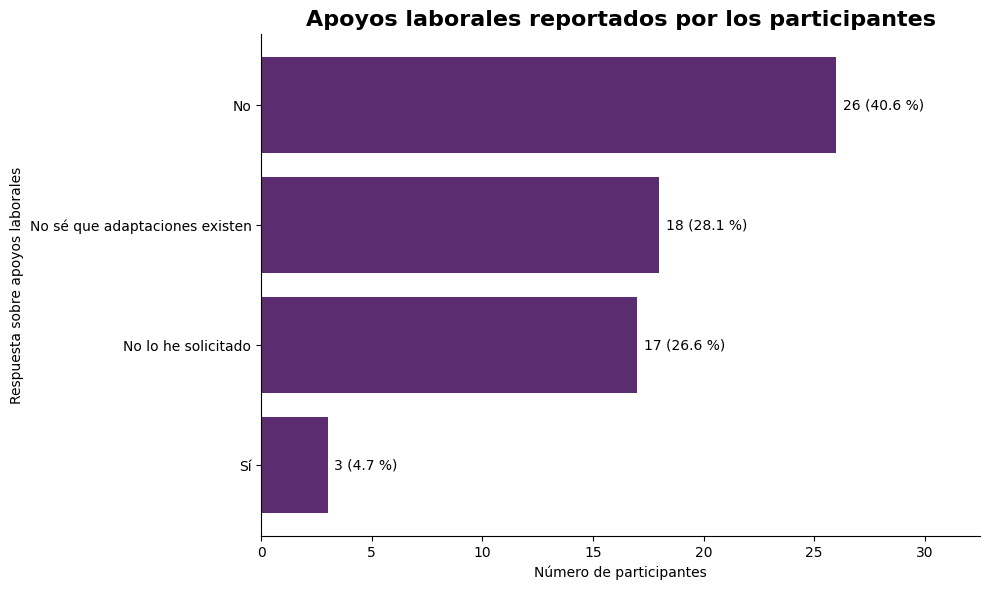

In [ ]:
# Gráfica de apoyos laborales reportados

datos_grafica = distribucion_apoyos.sort_values(
    'participantes',
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    datos_grafica.index,
    datos_grafica['participantes'],
    color=MORADO_PRINCIPAL
)

# Etiquetas con frecuencia y porcentaje
for barra, participantes, porcentaje in zip(
    barras,
    datos_grafica['participantes'],
    datos_grafica['porcentaje']
):
    ax.text(
        barra.get_width() + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f'{participantes} ({porcentaje:.1f} %)',
        va='center'
    )

ax.set_title(
    'Apoyos laborales reportados por los participantes',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de participantes')
ax.set_ylabel('Respuesta sobre apoyos laborales')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Espacio para las etiquetas
ax.set_xlim(
    0,
    datos_grafica['participantes'].max() * 1.25
)

plt.tight_layout()
plt.show()

## 6.4 Análisis de relaciones entre variables

Después de describir las características generales de la muestra, las características relacionadas con el TDAH y la situación laboral de los participantes, se exploraron relaciones entre variables con el propósito de identificar patrones dentro de la muestra analizada.

Debido al tamaño de la muestra y al carácter exploratorio del estudio, estos análisis se interpretan de manera descriptiva y no pretenden establecer relaciones causales ni generalizar los resultados a toda la población adulta con TDAH.

**6.4.1 Diagnóstico formal y situación laboral**

Se exploró la relación entre el diagnóstico formal de TDAH y la situación laboral actual de los participantes.

Para este análisis se utilizó la variable derivada `situacion_laboral`, que agrupa a los participantes en dos categorías generales: **Trabaja** y **No trabaja**. Los resultados se presentan mediante frecuencias y porcentajes dentro de cada categoría de diagnóstico formal.

Este análisis tiene un propósito exploratorio y descriptivo; por lo tanto, las diferencias observadas no implican causalidad.

In [ ]:
# Diagnóstico formal × situación laboral

tabla_diagnostico_laboral = pd.crosstab(
    df['diagnostico_formal'],
    df['situacion_laboral'],
    margins=True,
    margins_name='Total'
)

display(tabla_diagnostico_laboral)

situacion_laboral,No trabaja,Trabaja,Total
diagnostico_formal,,,
No,4,3,7
"No, pero sospecho que sí",2,16,18
Sí,7,32,39
Total,13,51,64


In [ ]:
# Porcentajes de situación laboral dentro de cada categoría
# de diagnóstico formal

porcentaje_diagnostico_laboral = pd.crosstab(
    df['diagnostico_formal'],
    df['situacion_laboral'],
    normalize='index'
).mul(100).round(1)

display(porcentaje_diagnostico_laboral)

situacion_laboral,No trabaja,Trabaja
diagnostico_formal,,
No,57.1,42.9
"No, pero sospecho que sí",11.1,88.9
Sí,17.9,82.1


**Diagnóstico formal y situación laboral**

Al analizar la situación laboral según el diagnóstico formal de TDAH, se observaron diferencias descriptivas entre los grupos.

Entre los **39 participantes con diagnóstico formal**, 32 (82.1 %) se encontraban trabajando y 7 (17.9 %) no trabajaban. Entre quienes indicaron **no contar con un diagnóstico formal, pero sospechar tener TDAH**, 16 de 18 participantes (88.9 %) trabajaban y 2 (11.1 %) no lo hacían.

Por otro lado, entre los **7 participantes que indicaron no contar con un diagnóstico formal**, 3 (42.9 %) trabajaban y 4 (57.1 %) no trabajaban.

Aunque se observan diferencias entre los grupos, estos resultados deben interpretarse con precaución debido al tamaño reducido y desigual de las categorías, particularmente entre los participantes sin diagnóstico formal. Por lo tanto, este análisis describe únicamente la distribución observada en la muestra y no permite establecer que el diagnóstico formal determine la situación laboral.

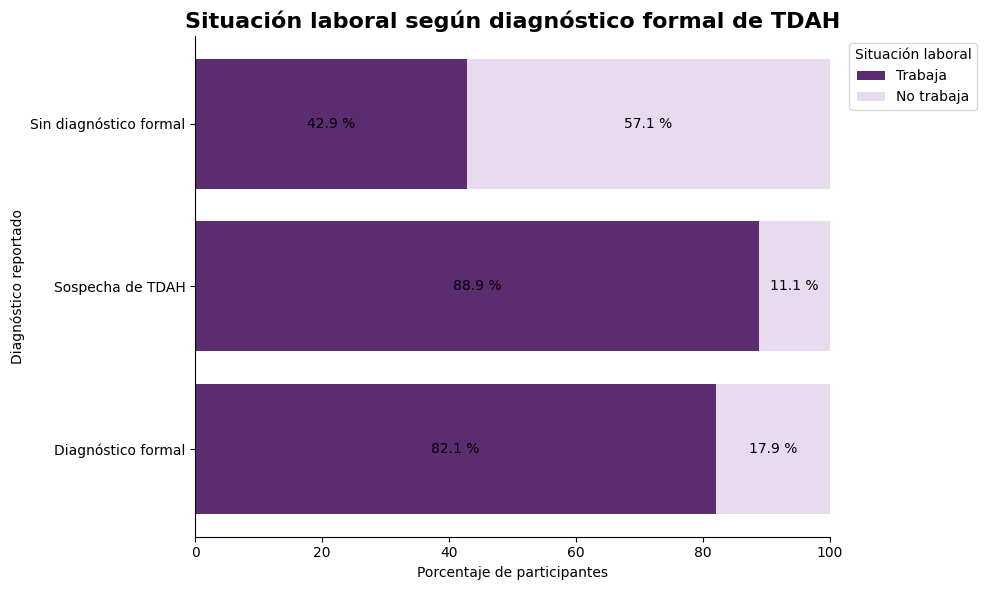

In [ ]:
# Gráfica: diagnóstico formal y situación laboral

# Porcentajes por categoría de diagnóstico
datos_grafica = porcentaje_diagnostico_laboral.copy()

# Orden de las categorías
orden = ['Sí', 'No, pero sospecho que sí', 'No']
datos_grafica = datos_grafica.reindex(orden)

# Nombres más breves para la visualización
etiquetas = [
    'Diagnóstico formal',
    'Sospecha de TDAH',
    'Sin diagnóstico formal'
]

fig, ax = plt.subplots(figsize=(10, 6))

# Barras apiladas al 100 %
ax.barh(
    etiquetas,
    datos_grafica['Trabaja'],
    label='Trabaja',
    color=MORADO_PRINCIPAL
)

ax.barh(
    etiquetas,
    datos_grafica['No trabaja'],
    left=datos_grafica['Trabaja'],
    label='No trabaja',
    color=LAVANDA
)

# Etiquetas de porcentaje dentro de cada segmento
for i, (_, fila) in enumerate(datos_grafica.iterrows()):

    trabaja = fila['Trabaja']
    no_trabaja = fila['No trabaja']

    ax.text(
        trabaja / 2,
        i,
        f'{trabaja:.1f} %',
        ha='center',
        va='center'
    )

    ax.text(
        trabaja + no_trabaja / 2,
        i,
        f'{no_trabaja:.1f} %',
        ha='center',
        va='center'
    )

ax.set_title(
    'Situación laboral según diagnóstico formal de TDAH',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Porcentaje de participantes')
ax.set_ylabel('Diagnóstico reportado')

ax.set_xlim(0, 100)

ax.legend(
    title='Situación laboral',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.4.2 Tipo de TDAH y situación laboral

Se exploró la distribución de la situación laboral según el tipo de TDAH reportado por los participantes.

Para este análisis se conservaron las categorías originales de la variable `tipo_tdah`, incluida la respuesta **No sé**, con el propósito de mantener la información proporcionada por los participantes sin asumir un subtipo de TDAH cuando este no fue identificado.

Los resultados se presentan mediante frecuencias absolutas y porcentajes dentro de cada categoría de tipo de TDAH.

In [ ]:
# Tipo de TDAH × situación laboral

tabla_tipo_laboral = pd.crosstab(
    df['tipo_tdah'],
    df['situacion_laboral'],
    margins=True,
    margins_name='Total'
)

display(tabla_tipo_laboral)

situacion_laboral,No trabaja,Trabaja,Total
tipo_tdah,,,
Combinado,9,19,28
Hiperactivo / Impulsivo,0,6,6
Inatento,0,13,13
No sé,4,13,17
Total,13,51,64


In [ ]:
# Porcentajes de situación laboral dentro de cada tipo de TDAH

porcentaje_tipo_laboral = pd.crosstab(
    df['tipo_tdah'],
    df['situacion_laboral'],
    normalize='index'
).mul(100).round(1)

display(porcentaje_tipo_laboral)

situacion_laboral,No trabaja,Trabaja
tipo_tdah,,
Combinado,32.1,67.9
Hiperactivo / Impulsivo,0.0,100.0
Inatento,0.0,100.0
No sé,23.5,76.5


**Tipo de TDAH y situación laboral**

Al explorar la situación laboral según el tipo de TDAH reportado, se observaron diferencias descriptivas entre las categorías.

Entre los **28 participantes que reportaron TDAH de tipo combinado**, 19 (67.9 %) se encontraban trabajando y 9 (32.1 %) no trabajaban. En el grupo de **TDAH inatento**, los 13 participantes (100 %) se encontraban trabajando, mientras que los 6 participantes (100 %) que reportaron **TDAH hiperactivo / impulsivo** también se encontraban trabajando.

Entre los 17 participantes que indicaron **no conocer su tipo de TDAH**, 13 (76.5 %) trabajaban y 4 (23.5 %) no lo hacían.

Aunque se observan diferencias entre las categorías, estos resultados deben interpretarse con precaución debido al tamaño reducido y desigual de los grupos. En particular, el grupo hiperactivo / impulsivo estuvo conformado por únicamente 6 participantes.

Por lo tanto, los resultados describen únicamente la distribución observada en la muestra y **no permiten concluir que un tipo de TDAH esté asociado con una mayor o menor probabilidad de encontrarse trabajando**.

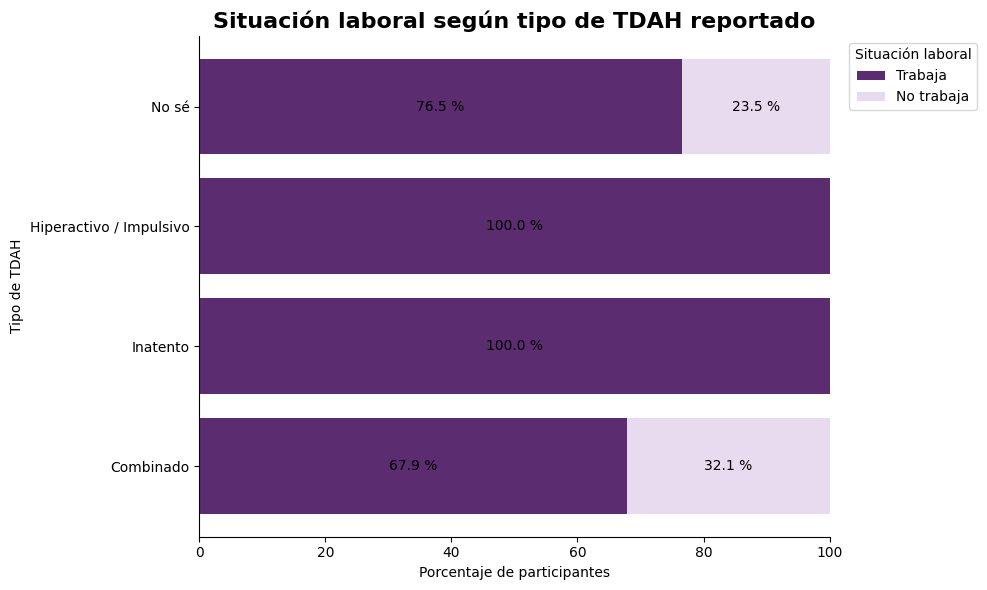

In [ ]:
# Gráfica: tipo de TDAH y situación laboral

datos_grafica = porcentaje_tipo_laboral.copy()

# Orden de las categorías
orden = [
    'Combinado',
    'Inatento',
    'Hiperactivo / Impulsivo',
    'No sé'
]

datos_grafica = datos_grafica.reindex(orden)

fig, ax = plt.subplots(figsize=(10, 6))

# Barras apiladas al 100 %
ax.barh(
    datos_grafica.index,
    datos_grafica['Trabaja'],
    label='Trabaja',
    color=MORADO_PRINCIPAL
)

ax.barh(
    datos_grafica.index,
    datos_grafica['No trabaja'],
    left=datos_grafica['Trabaja'],
    label='No trabaja',
    color=LAVANDA
)

# Etiquetas de porcentaje
for i, (_, fila) in enumerate(datos_grafica.iterrows()):

    trabaja = fila['Trabaja']
    no_trabaja = fila['No trabaja']

    # Mostrar porcentaje de quienes trabajan
    if trabaja > 0:
        ax.text(
            trabaja / 2,
            i,
            f'{trabaja:.1f} %',
            ha='center',
            va='center'
        )

    # Mostrar porcentaje de quienes no trabajan
    if no_trabaja > 0:
        ax.text(
            trabaja + no_trabaja / 2,
            i,
            f'{no_trabaja:.1f} %',
            ha='center',
            va='center'
        )

ax.set_title(
    'Situación laboral según tipo de TDAH reportado',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Porcentaje de participantes')
ax.set_ylabel('Tipo de TDAH')

ax.set_xlim(0, 100)

ax.legend(
    title='Situación laboral',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6.4.3 Tipo de TDAH y dificultades laborales

Se exploró la distribución de las dificultades laborales reportadas según el tipo de TDAH indicado por los participantes.

Para este análisis se utilizaron las categorías originales de `tipo_tdah` y la variable derivada `reporta_dificultad`, conservando las respuestas no determinadas con el propósito de mantener la trazabilidad de la información.

Los resultados se presentan mediante frecuencias y porcentajes dentro de cada categoría de tipo de TDAH. Debido al tamaño reducido y desigual de los grupos, este análisis tiene un propósito descriptivo y exploratorio.

In [ ]:
# Tipo de TDAH × reporte de dificultades laborales

tabla_tipo_dificultad = pd.crosstab(
    df['tipo_tdah'],
    df['reporta_dificultad'],
    margins=True,
    margins_name='Total'
)

display(tabla_tipo_dificultad)

reporta_dificultad,No,No determinado,Sí,Total
tipo_tdah,,,,
Combinado,0,0,28,28
Hiperactivo / Impulsivo,0,0,6,6
Inatento,0,0,13,13
No sé,5,1,11,17
Total,5,1,58,64


In [ ]:
# Porcentaje de dificultades laborales dentro de cada tipo de TDAH

porcentaje_tipo_dificultad = pd.crosstab(
    df['tipo_tdah'],
    df['reporta_dificultad'],
    normalize='index'
).mul(100).round(1)

display(porcentaje_tipo_dificultad)

reporta_dificultad,No,No determinado,Sí
tipo_tdah,,,
Combinado,0.0,0.0,100.0
Hiperactivo / Impulsivo,0.0,0.0,100.0
Inatento,0.0,0.0,100.0
No sé,29.4,5.9,64.7


**Tipo de TDAH y reporte de dificultades laborales**

Al analizar el reporte de dificultades laborales según el tipo de TDAH, se observó que **todos los participantes que reportaron un tipo específico de TDAH indicaron haber experimentado alguna dificultad laboral**.

En el grupo con TDAH **combinado**, los 28 participantes (100 %) reportaron dificultades laborales. El mismo patrón se observó entre los 13 participantes (100 %) que indicaron TDAH **inatento** y los 6 participantes (100 %) que reportaron TDAH **hiperactivo / impulsivo**.

En contraste, entre los 17 participantes que indicaron **no conocer su tipo de TDAH**, 11 (64.7 %) reportaron dificultades laborales, 5 (29.4 %) indicaron no haberlas experimentado y 1 (5.9 %) presentó una respuesta que no permitió determinarlo.

Estos resultados muestran que, dentro de la muestra analizada, el reporte de dificultades laborales fue muy frecuente entre quienes identificaron un tipo específico de TDAH. Sin embargo, **no permiten concluir que algún tipo de TDAH esté asociado con una mayor probabilidad de presentar dificultades laborales**, ya que los tres grupos específicos presentaron una frecuencia del 100 % y sus tamaños fueron reducidos y desiguales.

Además, la categoría **No sé** debe interpretarse de manera diferenciada, ya que representa desconocimiento del tipo de TDAH reportado y no constituye un subtipo clínico.

Por lo tanto, los resultados tienen un carácter descriptivo y exploratorio y corresponden únicamente a la muestra analizada.

### 6.4.4 Tipo de TDAH y categorías de dificultades laborales

Se exploraron las categorías temáticas de dificultades laborales según el tipo de TDAH reportado por los participantes.

Debido a que una misma respuesta podía contener más de una dificultad, las categorías temáticas no son mutuamente excluyentes. Por lo tanto, un mismo participante puede estar representado en varias categorías.

El análisis tiene un propósito descriptivo y exploratorio. Las diferencias observadas entre los tipos de TDAH deben interpretarse con precaución debido al tamaño reducido y desigual de los grupos.

In [ ]:
# Frecuencia de categorías de dificultad según tipo de TDAH

tabla_tipo_categorias = (
    df.groupby('tipo_tdah')[columnas_dificultades]
    .sum()
    .astype(int)
)

# Ordenar los grupos para facilitar la lectura
orden_tipos = [
    'Combinado',
    'Inatento',
    'Hiperactivo / Impulsivo',
    'No sé'
]

tabla_tipo_categorias = tabla_tipo_categorias.reindex(orden_tipos)

display(tabla_tipo_categorias)

,atencion_concentracion,organizacion_planificacion,gestion_tiempo_puntualidad,memoria_seguimiento,regulacion_emocional_estres,motivacion_aburrimiento,comunicacion_relaciones,impulsividad,sobrecarga_agotamiento,comprension_instrucciones,resolucion_problemas
tipo_tdah,,,,,,,,,,,
Combinado,1,3,6,3,3,6,4,0,1,1,0
Inatento,3,3,3,1,4,0,0,0,1,2,1
Hiperactivo / Impulsivo,1,2,3,0,0,0,1,1,0,0,0
No sé,4,0,0,1,0,1,0,0,0,0,0


In [ ]:
# Número de respuestas con detalle temático según tipo de TDAH

detalle_por_tipo = pd.crosstab(
    df['tipo_tdah'],
    df['detalle_dificultad']
)

detalle_por_tipo = detalle_por_tipo.reindex(orden_tipos)

display(detalle_por_tipo)

detalle_dificultad,Con detalle temático,Sin detalle suficiente,Sin dificultad reportada
tipo_tdah,,,
Combinado,16,12,0
Inatento,10,3,0
Hiperactivo / Impulsivo,6,0,0
No sé,5,7,5


In [ ]:
# Porcentaje de cada categoría de dificultad
# respecto a las respuestas con detalle temático de cada tipo de TDAH

n_detalle_por_tipo = (
    detalle_por_tipo['Con detalle temático']
    .reindex(orden_tipos)
)

porcentaje_tipo_categorias = (
    tabla_tipo_categorias
    .div(n_detalle_por_tipo, axis=0)
    .mul(100)
    .round(1)
)

display(porcentaje_tipo_categorias)

print("\nRespuestas con detalle temático utilizadas como denominador:")
display(
    n_detalle_por_tipo.to_frame(
        name='respuestas_con_detalle'
    )
)

,atencion_concentracion,organizacion_planificacion,gestion_tiempo_puntualidad,memoria_seguimiento,regulacion_emocional_estres,motivacion_aburrimiento,comunicacion_relaciones,impulsividad,sobrecarga_agotamiento,comprension_instrucciones,resolucion_problemas
tipo_tdah,,,,,,,,,,,
Combinado,6.2,18.8,37.5,18.8,18.8,37.5,25.0,0.0,6.2,6.2,0.0
Inatento,30.0,30.0,30.0,10.0,40.0,0.0,0.0,0.0,10.0,20.0,10.0
Hiperactivo / Impulsivo,16.7,33.3,50.0,0.0,0.0,0.0,16.7,16.7,0.0,0.0,0.0
No sé,80.0,0.0,0.0,20.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0



Respuestas con detalle temático utilizadas como denominador:


,respuestas_con_detalle
tipo_tdah,
Combinado,16
Inatento,10
Hiperactivo / Impulsivo,6
No sé,5


**Categorías de dificultades según tipo de TDAH**

La distribución de las categorías temáticas de dificultades laborales presentó variaciones descriptivas según el tipo de TDAH reportado.

Para este análisis se consideraron únicamente las **37 respuestas con detalle temático suficiente**, distribuidas de la siguiente manera: 16 participantes con TDAH combinado, 10 con TDAH inatento, 6 con TDAH hiperactivo / impulsivo y 5 que indicaron no conocer su tipo de TDAH.

Los porcentajes fueron calculados dentro de cada uno de estos grupos y las categorías no son mutuamente excluyentes, ya que una misma respuesta podía contener más de una dificultad.

Aunque se observan diferencias en la frecuencia relativa de las categorías entre los grupos, estas deben interpretarse únicamente como **patrones descriptivos de la muestra**. Los tamaños de los grupos son reducidos y desiguales, particularmente en las categorías hiperactivo / impulsivo y No sé, por lo que porcentajes elevados pueden corresponder a un número pequeño de participantes.

Por esta razón, los resultados no permiten establecer que determinadas categorías de dificultades laborales sean características de un tipo específico de TDAH ni realizar inferencias sobre la población general.

### 6.4.5 Situación laboral y dificultades laborales

Se exploró la distribución del reporte de dificultades laborales según la situación laboral actual de los participantes.

Para este análisis se utilizaron las variables derivadas `situacion_laboral` y `reporta_dificultad`. Se conservaron las respuestas clasificadas como **No determinado** para mantener la información disponible y la trazabilidad del proceso de limpieza.

Los resultados se presentan mediante frecuencias absolutas y porcentajes dentro de cada categoría de situación laboral. Este análisis tiene un propósito descriptivo y exploratorio y no permite establecer relaciones causales.

In [ ]:
# Situación laboral × reporte de dificultades laborales

tabla_laboral_dificultad = pd.crosstab(
    df['situacion_laboral'],
    df['reporta_dificultad'],
    margins=True,
    margins_name='Total'
)

display(tabla_laboral_dificultad)

reporta_dificultad,No,No determinado,Sí,Total
situacion_laboral,,,,
No trabaja,2,1,10,13
Trabaja,3,0,48,51
Total,5,1,58,64


In [ ]:
# Porcentaje de reporte de dificultades
# dentro de cada situación laboral

porcentaje_laboral_dificultad = pd.crosstab(
    df['situacion_laboral'],
    df['reporta_dificultad'],
    normalize='index'
).mul(100).round(1)

display(porcentaje_laboral_dificultad)

reporta_dificultad,No,No determinado,Sí
situacion_laboral,,,
No trabaja,15.4,7.7,76.9
Trabaja,5.9,0.0,94.1


**Situación laboral y reporte de dificultades**

Al analizar el reporte de dificultades laborales según la situación laboral actual, se observó una alta frecuencia de dificultades en ambos grupos.

Entre los **51 participantes que se encontraban trabajando**, 48 (94.1 %) reportaron alguna dificultad laboral, mientras que 3 (5.9 %) indicaron no haber experimentado dificultades.

Entre los **13 participantes que no se encontraban trabajando**, 10 (76.9 %) reportaron dificultades laborales, 2 (15.4 %) indicaron no haberlas experimentado y 1 (7.7 %) presentó una respuesta que no permitió determinarlo.

Descriptivamente, el reporte de dificultades fue más frecuente entre los participantes que se encontraban trabajando (94.1 %) que entre quienes no trabajaban (76.9 %). Sin embargo, esta diferencia debe interpretarse con precaución debido al tamaño reducido y desigual de los grupos y a la naturaleza de la variable analizada.

En particular, estos resultados **no permiten establecer que encontrarse trabajando provoque una mayor presencia de dificultades laborales ni que las dificultades reportadas determinen la situación laboral**. El análisis describe únicamente la distribución observada en la muestra.

### 6.4.6 Diagnóstico formal y apoyos laborales

Finalmente, se exploró la distribución de los apoyos laborales reportados según la situación de diagnóstico formal de TDAH.

Para este análisis se conservaron las cuatro categorías originales de `apoyos_laborales`: **Sí**, **No**, **No lo he solicitado** y **No sé qué adaptaciones existen**. Estas respuestas representan situaciones diferentes y, por lo tanto, no fueron agrupadas en una única categoría negativa.

Los resultados se presentan mediante frecuencias y porcentajes dentro de cada categoría de diagnóstico formal. Debido al tamaño reducido y desigual de los grupos, el análisis tiene un propósito descriptivo y exploratorio.

In [ ]:
# Diagnóstico formal × apoyos laborales

tabla_diagnostico_apoyos = pd.crosstab(
    df['diagnostico_formal'],
    df['apoyos_laborales'],
    margins=True,
    margins_name='Total'
)

display(tabla_diagnostico_apoyos)

apoyos_laborales,No,No lo he solicitado,No sé que adaptaciones existen,Sí,Total
diagnostico_formal,,,,,
No,5,1,1,0,7
"No, pero sospecho que sí",5,6,7,0,18
Sí,16,10,10,3,39
Total,26,17,18,3,64


In [ ]:
# Porcentajes de apoyos laborales
# dentro de cada categoría de diagnóstico formal

porcentaje_diagnostico_apoyos = pd.crosstab(
    df['diagnostico_formal'],
    df['apoyos_laborales'],
    normalize='index'
).mul(100).round(1)

display(porcentaje_diagnostico_apoyos)

apoyos_laborales,No,No lo he solicitado,No sé que adaptaciones existen,Sí
diagnostico_formal,,,,
No,71.4,14.3,14.3,0.0
"No, pero sospecho que sí",27.8,33.3,38.9,0.0
Sí,41.0,25.6,25.6,7.7


**Diagnóstico formal y apoyos laborales**

Al analizar los apoyos laborales según la situación de diagnóstico formal, se observó que el reporte de apoyos fue poco frecuente en todos los grupos.

Entre los **39 participantes con diagnóstico formal de TDAH**, 3 (7.7 %) indicaron recibir apoyos laborales, 16 (41.0 %) respondieron que no los recibían, 10 (25.6 %) señalaron que no los habían solicitado y 10 (25.6 %) indicaron no saber qué adaptaciones existen.

Entre los **18 participantes que no contaban con un diagnóstico formal, pero sospechaban tener TDAH**, ninguno reportó recibir apoyos laborales. En este grupo, 7 participantes (38.9 %) indicaron no saber qué adaptaciones existen, 6 (33.3 %) señalaron que no las habían solicitado y 5 (27.8 %) respondieron que no recibían apoyos.

De los **7 participantes que indicaron no contar con un diagnóstico formal**, ninguno reportó recibir apoyos laborales. Cinco (71.4 %) respondieron que no los recibían, mientras que 1 (14.3 %) indicó no haberlos solicitado y 1 (14.3 %) señaló no saber qué adaptaciones existen.

En esta muestra, los únicos participantes que reportaron recibir apoyos laborales pertenecían al grupo con diagnóstico formal. Sin embargo, este resultado corresponde únicamente a **3 participantes**, por lo que no permite establecer que contar con un diagnóstico formal esté asociado con un mayor acceso a apoyos laborales.

Asimismo, las diferencias observadas entre los grupos deben interpretarse con precaución debido al tamaño reducido y desigual de las categorías de diagnóstico. Los resultados tienen un carácter descriptivo y exploratorio y no permiten establecer relaciones causales.

## 6.5 Síntesis de hallazgos del análisis exploratorio

El análisis exploratorio permitió identificar las principales características de los 64 participantes y observar algunos patrones relacionados con el TDAH y su situación laboral.

### Características de la muestra

La muestra estuvo conformada principalmente por participantes de **México (93.8 %)**. La edad mediana fue de **36.5 años**, y el grupo de edad con mayor representación fue el de **25 a 39 años (57.8 %)**. En cuanto a la escolaridad, predominó el nivel universitario, reportado por 45 de los 64 participantes.

Respecto al diagnóstico, **39 participantes (60.9 %)** indicaron contar con un diagnóstico formal de TDAH, mientras que 18 (28.1 %) señalaron no tenerlo, pero sospechar presentar esta condición. Entre los participantes con diagnóstico formal, el tipo de TDAH reportado con mayor frecuencia fue el **combinado (48.7 %)**, seguido del **inatento (30.8 %)** y el **hiperactivo / impulsivo (15.4 %)**.

Entre los 38 participantes con diagnóstico formal y una edad de diagnóstico cuantificable, la mediana de edad al momento del diagnóstico fue de **33.5 años**.

### Situación laboral

En el momento de la encuesta, **51 participantes (79.7 %)** fueron clasificados como personas que trabajaban y 13 (20.3 %) como personas que no trabajaban.

La modalidad laboral más frecuente fue **tiempo completo (40.6 %)**, seguida de **freelance / independiente (23.4 %)** e **informal (12.5 %)**.

Las dificultades laborales fueron ampliamente reportadas en la muestra: **58 de los 64 participantes (90.6 %)** indicaron haber experimentado alguna dificultad relacionada con el ámbito laboral.

Entre las 37 respuestas que proporcionaron suficiente detalle para realizar una clasificación temática, la categoría identificada con mayor frecuencia fue **gestión del tiempo y puntualidad (32.4 %)**, seguida de **atención y concentración (24.3 %)** y **organización y planificación (21.6 %)**.

Además, **16 de estos 37 participantes (43.2 %)** presentaron dificultades correspondientes a dos o más categorías temáticas, lo que muestra que las experiencias descritas frecuentemente involucraron más de un ámbito.

### Apoyos laborales

El reporte de apoyos o adaptaciones laborales fue poco frecuente. Únicamente **3 de los 64 participantes (4.7 %)** indicaron recibirlos.

Por otra parte, 26 participantes (40.6 %) respondieron que no recibían apoyos, 18 (28.1 %) indicaron **no saber qué adaptaciones existen** y 17 (26.6 %) señalaron que **no las habían solicitado**.

### Relaciones exploradas

Los cruces entre variables permitieron identificar algunos patrones descriptivos dentro de la muestra.

Entre los participantes con diagnóstico formal, **82.1 % se encontraba trabajando**, mientras que entre quienes sospechaban tener TDAH la proporción fue de 88.9 %. En el grupo que indicó no contar con diagnóstico formal, 42.9 % se encontraba trabajando. Estas diferencias deben interpretarse con precaución debido al tamaño reducido y desigual de los grupos.

Según el tipo de TDAH reportado, se encontraba trabajando el **67.9 % del grupo combinado**, el **100 % del grupo inatento**, el **100 % del grupo hiperactivo / impulsivo** y el **76.5 % de quienes indicaron no conocer su tipo de TDAH**. Los tamaños reducidos de algunas categorías impiden interpretar estas diferencias como evidencia de una asociación entre el tipo de TDAH y la situación laboral.

El reporte de dificultades laborales fue elevado tanto entre quienes trabajaban como entre quienes no lo hacían: **94.1 % de los participantes que trabajaban** y **76.9 % de quienes no trabajaban** reportaron alguna dificultad laboral.

Asimismo, todos los participantes que reportaron un tipo específico de TDAH indicaron haber experimentado alguna dificultad laboral. Sin embargo, este resultado no permite determinar diferencias entre los tipos de TDAH ni establecer relaciones causales.

Finalmente, los únicos participantes que indicaron recibir apoyos laborales pertenecían al grupo con diagnóstico formal; no obstante, se trató únicamente de **3 participantes**, por lo que este resultado debe considerarse descriptivo.

### Consideraciones generales

En conjunto, los resultados muestran que las dificultades laborales fueron frecuentes dentro de la muestra analizada, particularmente aquellas relacionadas con la gestión del tiempo, la atención y la organización. Al mismo tiempo, el reporte de apoyos laborales fue poco frecuente y una proporción relevante de participantes indicó desconocer qué adaptaciones laborales existen.

Sin embargo, los resultados deben interpretarse considerando las características y limitaciones de la muestra. El tamaño total fue reducido, algunos grupos estuvieron conformados por pocos participantes y la distribución geográfica estuvo fuertemente concentrada en México. Además, varias variables corresponden a información autorreportada.

Por lo tanto, los patrones identificados tienen un carácter **descriptivo y exploratorio**. Los resultados permiten caracterizar la experiencia laboral de los participantes de esta muestra y generar preguntas para análisis posteriores, pero **no permiten establecer causalidad ni generalizar los hallazgos a toda la población adulta con TDAH en Latinoamérica**.

## 7. Conclusiones

El presente proyecto tuvo como propósito explorar la relación entre el TDAH y la situación laboral a partir de una muestra de **64 participantes**, mediante un proceso de limpieza, transformación, análisis descriptivo y exploración de relaciones entre variables.

Los resultados muestran que las **dificultades laborales fueron frecuentes dentro de la muestra**, ya que 58 participantes (90.6 %) reportaron haber experimentado alguna. Entre las respuestas que proporcionaron suficiente información para realizar una clasificación temática, destacaron principalmente las dificultades relacionadas con la **gestión del tiempo y puntualidad**, la **atención y concentración** y la **organización y planificación**.

Además, las dificultades descritas no siempre se limitaron a un solo ámbito. Entre las 37 respuestas con detalle temático, 16 participantes (43.2 %) presentaron dificultades correspondientes a dos o más categorías, lo que refleja la diversidad de experiencias laborales reportadas.

A pesar de la elevada frecuencia de dificultades, la mayoría de los participantes se encontraba trabajando al momento de responder la encuesta. En total, 51 personas (79.7 %) fueron clasificadas dentro del grupo que trabajaba, frente a 13 (20.3 %) que no trabajaban. Esto muestra que, dentro de esta muestra, **reportar dificultades laborales no implicó necesariamente encontrarse fuera del mercado laboral**.

Los análisis realizados según diagnóstico formal y tipo de TDAH mostraron algunas diferencias descriptivas en la situación laboral. Sin embargo, los tamaños reducidos y desiguales de los grupos no permiten establecer que contar con un diagnóstico formal o presentar determinado tipo de TDAH esté asociado con una mayor o menor probabilidad de encontrarse trabajando.

Otro resultado relevante fue la baja frecuencia de apoyos laborales reportados. Solamente 3 participantes (4.7 %) indicaron recibir algún apoyo o adaptación, mientras que una parte de la muestra señaló no haberlos solicitado o desconocer qué adaptaciones existen. Este resultado plantea la importancia de continuar explorando el conocimiento, acceso y utilización de apoyos laborales entre adultos con TDAH.

### 7.1 Limitaciones

Los resultados deben interpretarse considerando diversas limitaciones. La muestra estuvo conformada por únicamente 64 participantes y presentó una fuerte concentración geográfica en México, por lo que no puede considerarse representativa de la población adulta con TDAH en Latinoamérica.

Asimismo, la información fue autorreportada y algunos grupos utilizados en las comparaciones estuvieron conformados por pocos participantes. La clasificación temática de las dificultades laborales se realizó de manera exploratoria a partir de respuestas abiertas y no corresponde a una escala clínica validada.

Por estas razones, los resultados obtenidos permiten identificar patrones dentro de la muestra, pero **no permiten establecer relaciones causales ni generalizar los hallazgos a toda la población**.

### 7.2 Trabajo futuro

Como continuación de este proyecto sería recomendable ampliar el tamaño y diversidad geográfica de la muestra, incorporar variables adicionales relacionadas con las condiciones laborales y utilizar instrumentos estandarizados que permitan evaluar de manera más precisa el impacto de las dificultades asociadas con el TDAH.

También sería de interés profundizar en el análisis de los apoyos y adaptaciones laborales, así como explorar qué estrategias utilizan las personas con TDAH para gestionar dificultades relacionadas con la atención, la organización, la gestión del tiempo y otras áreas identificadas durante el análisis.

En conjunto, este proyecto permitió transformar las respuestas de una encuesta en información estructurada y analizar de manera exploratoria diferentes aspectos de la experiencia laboral reportada por los participantes. Los resultados constituyen un punto de partida para comprender mejor estas experiencias y para plantear nuevas preguntas que puedan abordarse mediante estudios con muestras más amplias y diseños metodológicos más robustos.